# 02 - Eksploratorna analiza podatka

## Uvodne napomene

### Cilj

U ovom notebook-u, biće izvršena eksploratorna analiza podataka (EDA) o kalcijumskom odgovoru nervnih ćelija na tretmane kalijumom i CSF-om. Podaci će se pribaviti primarno iz fajla `roi_features_modeling.csv`, dobijenog ekstrakcijom vrednosti iz fajlova koji sadrže eksperimentalne podatke, u okviru notebook-a `01_extract_features.ipynb`.

## Učitavanje podataka

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def find_project_root(
    start: Path | None = None,
) -> Path:
    """
    Locira osnovni folder projekta pretragom trenutne direktorije
    i foldera višeg reda.

    Osnovni folder mora sadržati:
    - environment.yml
    - notebooks/
    """
    start = (
        Path.cwd()
        if start is None
        else Path(start)
    ).resolve()

    for candidate in [
        start,
        *start.parents,
    ]:
        if (
            (candidate / "environment.yml").is_file()
            and (candidate / "notebooks").is_dir()
        ):
            return candidate

    raise FileNotFoundError(
        "Osnovni folder nije pronađen. Uverite se da "
        "environment.yml, i notebooks/ postoje "
        "u glavnom folderu projekta."
    )

In [3]:
def save_figure(
    fig,
    file_stem: str,
    dpi: int = 300,
) -> None:
    """
    Čuva grafik EDA kao PNG i PDF.
    """
    png_path = (
        EDA_FIGURES_DIR
        / f"{file_stem}.png"
    )

    pdf_path = (
        EDA_FIGURES_DIR
        / f"{file_stem}.pdf"
    )

    fig.savefig(
        png_path,
        dpi=dpi,
        bbox_inches="tight",
    )

    fig.savefig(
        pdf_path,
        bbox_inches="tight",
    )

In [4]:
# Definisanje odgovarajućih foldera
PROJECT_ROOT = find_project_root()

UNPACKED_DIR = (
    PROJECT_ROOT 
    / "data" 
    / "unpacked" 
    / "1_25"
)

EXTRACTED_DIR = (
    PROJECT_ROOT
    / "data"
    / "extracted"
)

MODELING_TABLE_PATH = (
    EXTRACTED_DIR
    / "roi_features_modeling.csv"
)

EDA_FIGURES_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "eda"
)

EDA_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not MODELING_TABLE_PATH.is_file():
    raise FileNotFoundError(
        "Tabela za analizu nije pronađena:\n"
        f"{MODELING_TABLE_PATH}\n\n"
        "Prvo pokrenite 01_extract_features.ipynb."
    )

print("Osnovni folder projekta:", PROJECT_ROOT)
print("Ulazna tabela:", MODELING_TABLE_PATH)
print("EDA grafici:", EDA_FIGURES_DIR)

Osnovni folder projekta: /home/pera/Faks/Master/MasterProjekatPetarJ
Ulazna tabela: /home/pera/Faks/Master/MasterProjekatPetarJ/data/extracted/roi_features_modeling.csv
EDA grafici: /home/pera/Faks/Master/MasterProjekatPetarJ/results/figures/eda


In [5]:
# Provera
print(MODELING_TABLE_PATH.exists())
print(MODELING_TABLE_PATH)

True
/home/pera/Faks/Master/MasterProjekatPetarJ/data/extracted/roi_features_modeling.csv


Definisali smo strukturu našeg projekta kao u prethodnom notebook-u i potvrdili lokaciju tabele. Sada ćemo je učitati i preći na EDA.

In [6]:
df = pd.read_csv(MODELING_TABLE_PATH)

df.shape

(997, 76)

In [7]:
df.head()

,record_id,experiment_id,file_name,relative_path,patient_id,class_label,dilution,roi_id,roi_source_excel_column,normalized_negative_fraction,...,csf_fit_duplicate_matches,k_ref_fit_valid,csf_fit_valid,exclude_primary_analysis,exclusion_reason,normalized_sheet,k_summary_sheet,k_fit_sheet,csf_summary_sheet,csf_fit_sheet
0,patient_10a_exp_1__ROI_001,patient_10a_exp_1,2023_11_01_CGNs_isolated3010_CSF_3.xlsx,10a_1..25/2023_11_01_CGNs_isolated3010_CSF_3.xlsx,10a,SMA,1_25,ROI_001,B,0.034646,...,NaN,True,True,False,NaN,Sheet2,Sheet3,Sheet4,Sheet7,Sheet8
1,patient_10a_exp_1__ROI_002,patient_10a_exp_1,2023_11_01_CGNs_isolated3010_CSF_3.xlsx,10a_1..25/2023_11_01_CGNs_isolated3010_CSF_3.xlsx,10a,SMA,1_25,ROI_002,C,0.000000,...,NaN,True,True,False,NaN,Sheet2,Sheet3,Sheet4,Sheet7,Sheet8
2,patient_10a_exp_1__ROI_003,patient_10a_exp_1,2023_11_01_CGNs_isolated3010_CSF_3.xlsx,10a_1..25/2023_11_01_CGNs_isolated3010_CSF_3.xlsx,10a,SMA,1_25,ROI_003,D,0.012598,...,NaN,True,True,False,NaN,Sheet2,Sheet3,Sheet4,Sheet7,Sheet8
3,patient_10a_exp_1__ROI_005,patient_10a_exp_1,2023_11_01_CGNs_isolated3010_CSF_3.xlsx,10a_1..25/2023_11_01_CGNs_isolated3010_CSF_3.xlsx,10a,SMA,1_25,ROI_005,F,0.050394,...,NaN,True,True,False,NaN,Sheet2,Sheet3,Sheet4,Sheet7,Sheet8
4,patient_10a_exp_1__ROI_006,patient_10a_exp_1,2023_11_01_CGNs_isolated3010_CSF_3.xlsx,10a_1..25/2023_11_01_CGNs_isolated3010_CSF_3.xlsx,10a,SMA,1_25,ROI_006,G,0.070079,...,NaN,True,True,False,NaN,Sheet2,Sheet3,Sheet4,Sheet7,Sheet8


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 76 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   record_id                     997 non-null    str    
 1   experiment_id                 997 non-null    str    
 2   file_name                     997 non-null    str    
 3   relative_path                 997 non-null    str    
 4   patient_id                    997 non-null    str    
 5   class_label                   997 non-null    str    
 6   dilution                      997 non-null    str    
 7   roi_id                        997 non-null    str    
 8   roi_source_excel_column       997 non-null    str    
 9   normalized_negative_fraction  997 non-null    float64
 10  majority_negative_trace       997 non-null    bool   
 11  k_ref_amplitude               996 non-null    float64
 12  k_ref_half_width              996 non-null    float64
 13  k_ref_peak_locat

Sve zasad izgleda dobro i u skladu sa očekivanjima.

## EDA

In [9]:
# Pregled broja ćelija za svako neurodegenerativno stanje
df["class_label"].value_counts()

class_label
SMA        545
ALS        269
Control    183
Name: count, dtype: int64

In [10]:
# Grupisanje prema neurodegenerativnom stanju i pacijentu
df.groupby(["class_label", "patient_id"]).size()

class_label  patient_id
ALS          3             163
             4             106
Control      7             183
SMA          10a           230
             10b           315
dtype: int64

Sada ćemo napraviti tabelu koja će služiti kao pregled svih Excel fajlova od kojih je svaki asociran sa jednim eksperimentom.

In [11]:
experiment_overview = (
    df
    .groupby(
        [
            "experiment_id",
            "patient_id",
            "class_label",
            "file_name",
        ],
        dropna=False,
    )
    .agg(
        n_rois=("record_id", "count"),
        k_responses=("k_ref_response_detected", "sum"),
        csf_responses=("csf_response_detected", "sum"),
        csf_nonresponses=("csf_response_detected", lambda x: (~x).sum()),
        csf_multiple_responses=("csf_multiple_responses", "sum"),
        k_valid_fits=("k_ref_fit_valid", "sum"),
        csf_valid_fits=("csf_fit_valid", "sum"),
    )
    .reset_index()
)

experiment_overview

,experiment_id,patient_id,class_label,file_name,n_rois,k_responses,csf_responses,csf_nonresponses,csf_multiple_responses,k_valid_fits,csf_valid_fits
0,patient_10a_exp_1,10a,SMA,2023_11_01_CGNs_isolated3010_CSF_3.xlsx,230,229,216,14,10,227,214
1,patient_10b_exp_1,10b,SMA,2023_07_10_CGNs_isolated0807_CSF_2_480nm-fitc_...,171,171,11,160,1,161,10
2,patient_10b_exp_2,10b,SMA,2023_07_10_CGNs_isolated0807_CSF_9_480nm-fitc_...,144,144,23,121,6,140,22
3,patient_3_exp_1,3,ALS,2024_02_16_CGNs_iso1302_4.xlsx,163,163,147,16,0,161,146
4,patient_4_exp_1,4,ALS,2023_11_11_CGNs_isolated0911_CSF_5_min0.1.xlsx,106,106,97,9,7,103,95
5,patient_7_exp_1,7,Control,2023_07_17_CGNs_isolated1407_CSF_5_480nm-fitc_...,183,183,181,2,20,181,179


U tabelu ćemo dodati stope odgovora ćelija na svaki tretman za svaki eksperiment.

In [12]:
experiment_overview["k_response_rate"] = (
    experiment_overview["k_responses"]
    / experiment_overview["n_rois"]
)

experiment_overview["csf_response_rate"] = (
    experiment_overview["csf_responses"]
    / experiment_overview["n_rois"]
)

experiment_overview["csf_multiple_response_rate"] = (
    experiment_overview["csf_multiple_responses"]
    / experiment_overview["n_rois"]
)

experiment_overview

,experiment_id,patient_id,class_label,file_name,n_rois,k_responses,csf_responses,csf_nonresponses,csf_multiple_responses,k_valid_fits,csf_valid_fits,k_response_rate,csf_response_rate,csf_multiple_response_rate
0,patient_10a_exp_1,10a,SMA,2023_11_01_CGNs_isolated3010_CSF_3.xlsx,230,229,216,14,10,227,214,0.995652,0.939130,0.043478
1,patient_10b_exp_1,10b,SMA,2023_07_10_CGNs_isolated0807_CSF_2_480nm-fitc_...,171,171,11,160,1,161,10,1.000000,0.064327,0.005848
2,patient_10b_exp_2,10b,SMA,2023_07_10_CGNs_isolated0807_CSF_9_480nm-fitc_...,144,144,23,121,6,140,22,1.000000,0.159722,0.041667
3,patient_3_exp_1,3,ALS,2024_02_16_CGNs_iso1302_4.xlsx,163,163,147,16,0,161,146,1.000000,0.901840,0.000000
4,patient_4_exp_1,4,ALS,2023_11_11_CGNs_isolated0911_CSF_5_min0.1.xlsx,106,106,97,9,7,103,95,1.000000,0.915094,0.066038
5,patient_7_exp_1,7,Control,2023_07_17_CGNs_isolated1407_CSF_5_480nm-fitc_...,183,183,181,2,20,181,179,1.000000,0.989071,0.109290


Odmah vidimo da ćelije gotovo univerzalno reaguju na kalijum, a da je stopa odgovora na CSF varijabilnija. Sada ćemo ove vrednosti pregrupisati tako da budu prikazane za svaku klasu.

In [13]:
class_response_summary = (
    df
    .groupby("class_label", dropna=False)
    .agg(
        n_rois=("record_id", "count"),
        k_responses=("k_ref_response_detected", "sum"),
        csf_responses=("csf_response_detected", "sum"),
        csf_nonresponses=("csf_response_detected", lambda x: (~x).sum()),
        csf_multiple_responses=("csf_multiple_responses", "sum"),
        k_valid_fits=("k_ref_fit_valid", "sum"),
        csf_valid_fits=("csf_fit_valid", "sum"),
    )
    .reset_index()
)

class_response_summary["k_response_rate"] = (
    class_response_summary["k_responses"]
    / class_response_summary["n_rois"]
)

class_response_summary["csf_response_rate"] = (
    class_response_summary["csf_responses"]
    / class_response_summary["n_rois"]
)

class_response_summary["csf_multiple_response_rate"] = (
    class_response_summary["csf_multiple_responses"]
    / class_response_summary["n_rois"]
)

class_response_summary

,class_label,n_rois,k_responses,csf_responses,csf_nonresponses,csf_multiple_responses,k_valid_fits,csf_valid_fits,k_response_rate,csf_response_rate,csf_multiple_response_rate
0,ALS,269,269,244,25,7,264,241,1.000000,0.907063,0.026022
1,Control,183,183,181,2,20,181,179,1.000000,0.989071,0.109290
2,SMA,545,544,250,295,17,528,246,0.998165,0.458716,0.031193


Sada ćemo pogledati koje od najvažnijih vrednosti nedostaju za određeni udeo ćelija.

In [14]:
# Definisanje najvažnijih kolona
key_feature_columns = [
    "k_ref_amplitude",
    "k_ref_half_width",
    "k_ref_peak_location",
    "k_ref_integral",
    "k_ref_free_coef",
    "k_ref_coef_fast",
    "k_ref_tau_fast",
    "k_ref_coef_slow",
    "k_ref_tau_slow",
    "k_ref_gof",
    "k_ref_percent_fast",

    "csf_amplitude",
    "csf_half_width",
    "csf_peak_location",
    "csf_integral",
    "csf_free_coef",
    "csf_coef_fast",
    "csf_tau_fast",
    "csf_coef_slow",
    "csf_tau_slow",
    "csf_gof",
    "csf_percent_fast",
]

# Provera nedostajućih vrednosti
missingness = (
    df[key_feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame(name="missing_fraction")
)

missingness

,missing_fraction
csf_tau_fast,0.331996
csf_coef_fast,0.331996
csf_gof,0.331996
csf_tau_slow,0.331996
csf_percent_fast,0.331996
csf_coef_slow,0.331996
csf_free_coef,0.331996
csf_amplitude,0.322969
csf_peak_location,0.322969
csf_half_width,0.322969


Vidimo da se nedostajuće vrednosti uglavnom odnose na koeficijente CSF fita, što je i očekivano, uzevši u obzir da bilo koji nedostajući odgovor sa sobom povlači nedostatak fita.

Sada ćemo početi sa jednostavnom vizuelizacijom našeg seta podataka, i to prvo sa parametrima kalcijumskog odgovora.

### Parametri kalcijumskog odgovora

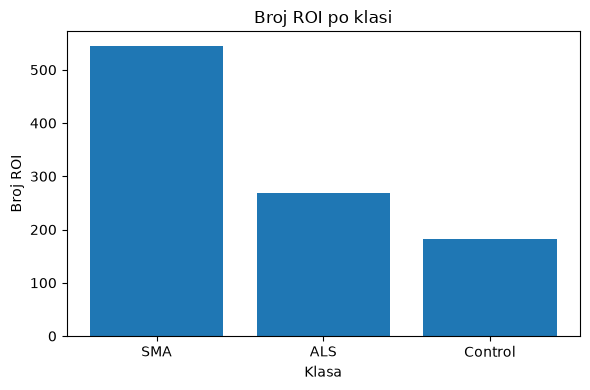

In [15]:
# Raspored po klasama
class_counts = df["class_label"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(class_counts.index, class_counts.values)
plt.xlabel("Klasa")
plt.ylabel("Broj ROI")
plt.title("Broj ROI po klasi")
plt.tight_layout()
plt.show()

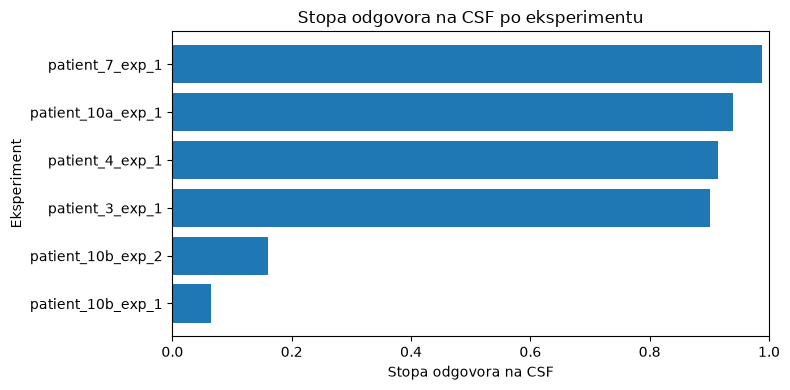

In [16]:
# Stopa odgovora na CSF po eksperimentu
plot_data = experiment_overview.sort_values("csf_response_rate")

plt.figure(figsize=(8, 4))
plt.barh(plot_data["experiment_id"], plot_data["csf_response_rate"])
plt.xlabel("Stopa odgovora na CSF")
plt.ylabel("Eksperiment")
plt.title("Stopa odgovora na CSF po eksperimentu")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

Uprkos tome što sve ćelije pouzdano odgovaraju na tretman kalijumom, ćelije tretirane CSF-om poreklom od pacijenta `10b` (SMA) pokazuju veoma slab odgovor na tretman CSF-om, što je interesantno.

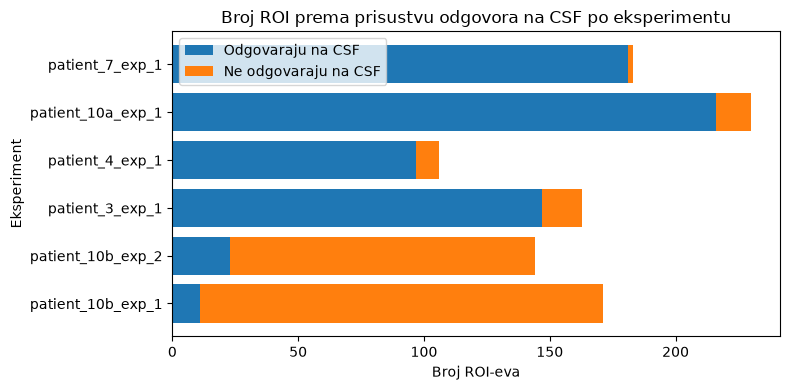

In [17]:
# Apsolutni broj ćelija koje (ne) odgovaraju na CSF
plot_data = experiment_overview.sort_values("csf_response_rate")

plt.figure(figsize=(8, 4))
plt.barh(
    plot_data["experiment_id"],
    plot_data["csf_responses"],
    label="Odgovaraju na CSF",
)
plt.barh(
    plot_data["experiment_id"],
    plot_data["csf_nonresponses"],
    left=plot_data["csf_responses"],
    label="Ne odgovaraju na CSF",
)

plt.xlabel("Broj ROI-eva")
plt.ylabel("Eksperiment")
plt.title("Broj ROI prema prisustvu odgovora na CSF po eksperimentu")
plt.legend()
plt.tight_layout()
plt.show()

Sada smo još jasnije prikazali veliku razliku u broju ćelija koje odgovaraju, odnosno ne odgovaraju na CSF u slučaju pacijenta `10b`.

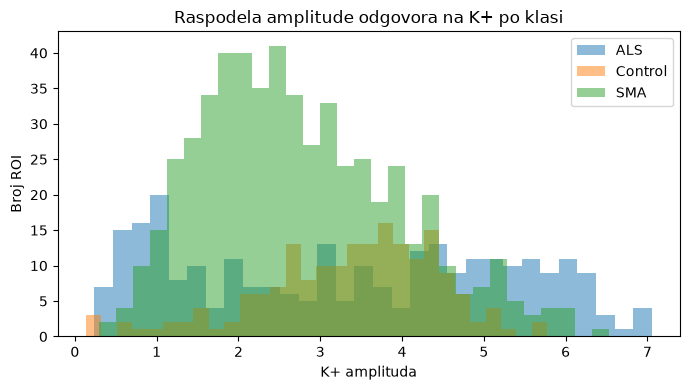

In [18]:
# Raspodela amplitude odgovora na kalijum po klasi
plt.figure(figsize=(7, 4))

for class_label, group in df.groupby("class_label"):
    plt.hist(
        group["k_ref_amplitude"].dropna(),
        bins=30,
        alpha=0.5,
        label=class_label,
    )

plt.xlabel("K+ amplituda")
plt.ylabel("Broj ROI")
plt.title("Raspodela amplitude odgovora na K+ po klasi")
plt.legend()
plt.tight_layout()
plt.show()

Zanimljivo je da ovde primećujemo izvesne razlike. Ćelije u eksperimentima sa SMA CSF-om pokazuju raspodelu sa relativno dobro definisanim vrhom. U slučaju kontrole, prosečna vrednost amplitude deluje više, ali je prisutna i veća varijansa. U slučaju eksperimenata sa ALS CSF-om, varijansa je vrlo visoka.

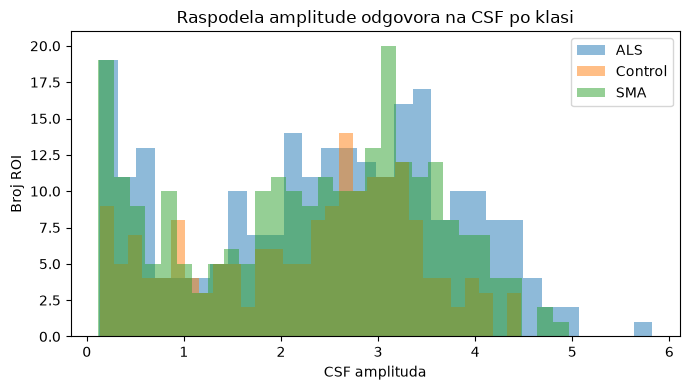

In [19]:
# Raspodela amplitude odgovora na CSF po klasi
csf_responders = df.loc[df["csf_response_detected"]].copy()

plt.figure(figsize=(7, 4))

for class_label, group in csf_responders.groupby("class_label"):
    plt.hist(
        group["csf_amplitude"].dropna(),
        bins=30,
        alpha=0.5,
        label=class_label,
    )

plt.xlabel("CSF amplituda")
plt.ylabel("Broj ROI")
plt.title("Raspodela amplitude odgovora na CSF po klasi")
plt.legend()
plt.tight_layout()
plt.show()

Možda je neobično to što je amplituda odgovora na CSF daleko ujednačenija među klasama. Samo po sebi, ovo bi sugerisalo da kalcijumski odgovor nije informativan, ali uzimajući u obzir činjenicu da varijabilan odgovor ćelija na tretman kalijumom (koji je uvek isti, ili barem veoma sličan po prirodi) sugeriše određene fiziološke razlike u samim neuronima, ima prostora za dalje ispitivanje.

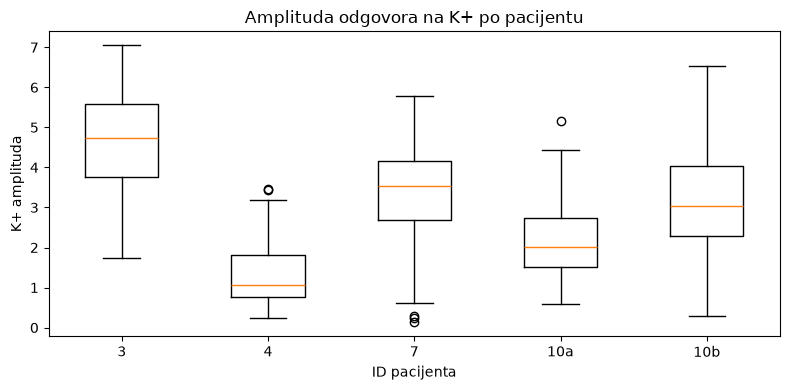

In [20]:
# Boksplot amplitude odgovora na K+ po pacijentu
plt.figure(figsize=(8, 4))

patient_order = (
    df.groupby("patient_id")["class_label"]
    .first()
    .sort_values()
    .index
)

data_to_plot = [
    df.loc[df["patient_id"] == patient_id, "k_ref_amplitude"].dropna()
    for patient_id in patient_order
]

plt.boxplot(data_to_plot, tick_labels=patient_order)
plt.xlabel("ID pacijenta")
plt.ylabel("K+ amplituda")
plt.title("Amplituda odgovora na K+ po pacijentu")
plt.tight_layout()
plt.show()

Ovde vidimo raspodelu amplitude odgovora na kalijum, dodatno podeljenu prema svakom pacijentu. Rezultat se uglavnom slaže sa onim što smo videli iznad, mada je interesantna razlika među pacijentima `3` i `4`, koji su predstavnici ALS klase.

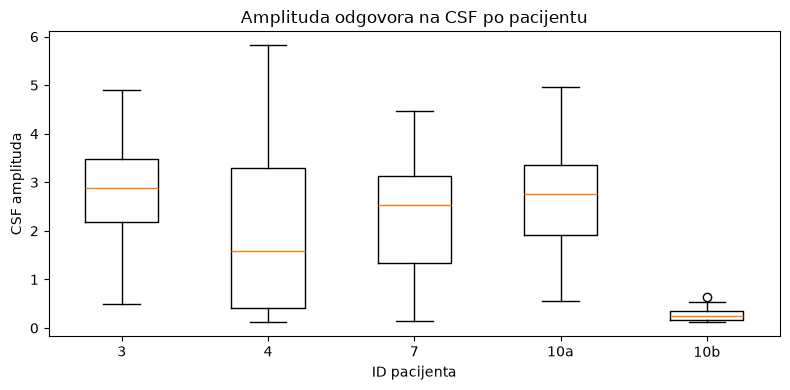

In [21]:
plt.figure(figsize=(8, 4))

data_to_plot = [
    csf_responders.loc[
        csf_responders["patient_id"] == patient_id,
        "csf_amplitude",
    ].dropna()
    for patient_id in patient_order
]

plt.boxplot(data_to_plot, tick_labels=patient_order)
plt.xlabel("ID pacijenta")
plt.ylabel("CSF amplituda")
plt.title("Amplituda odgovora na CSF po pacijentu")
plt.tight_layout()
plt.show()

Vidimo da je raspodela odgovora prilično ujednačena za 4 od 5 pacijenata, sa velikim odstupanjem u slučaju pacijenta `10b`, što je potencijalno interesantno - ćelije u tim eksperimentima uglavnom ne reaguju na CSF, a i kada reaguju, reaguju slabo, i to uprkos činjenici da na kalijum reaguju sasvim regularno. Vredi obratiti pažnju i na prilično široku raspodelu odgovora u slučaju pacijenta `4`.

Sada ćemo, radi ilustracije, grafički prikazati nekoliko normalizovanih zapisa fluorescencije, da bismo videli kakve podatke u stvari analiziramo. Posmatraćemo tri slučaja:
- primer jakog odgovora na CSF (ALS uzorak, pacijent `4`)
- primer izostanka odgovora na CSF (SMA uzorak, pacijent `10b`)
- primer kontrolnog uzorka (pacijent `7`)

Definisaćemo funkciju koja pretvara slovne oznake kolona u Excel fajlu u numerički indeks, koja će nam koristiti za ekstrakciju vrednosti fluorescencije.

In [22]:
def excel_column_letter_to_index(column_letter: str) -> int:
    """
    Prevodi slovne oznake kolona u Excel-u u numerički indeks.

    Primer:
        A  -> 0
        B  -> 1
        Z  -> 25
        AA -> 26
    """
    column_letter = column_letter.upper().strip()

    index = 0

    for char in column_letter:
        index = index * 26 + (ord(char) - ord("A") + 1)

    return index - 1

Ovu funkciju ćemo iskoristiti da bismo došli do kolone koja sadrži informacije o vrednostima fluorescencije za dati ROI u izvornom .xlsx fajlu.

In [23]:
def load_normalized_roi_trace(row: pd.Series) -> pd.DataFrame:
    """
    Učitava vrednosti normalizovane fluorescencije za jedan ROI
    iz drugog lista odgovarajućeg originalnog Excel fajla.
    """
    workbook_path = UNPACKED_DIR / row["relative_path"]

    sheet = pd.read_excel(
        workbook_path,
        sheet_name="Sheet2",
        header=None,
    )

    time = pd.to_numeric(
        sheet.iloc[:, 0],
        errors="coerce",
    )

    roi_column_index = excel_column_letter_to_index(
        row["roi_source_excel_column"]
    )

    fluorescence = pd.to_numeric(
        sheet.iloc[:, roi_column_index],
        errors="coerce",
    )

    trace = pd.DataFrame(
        {
            "time_s": time,
            "normalized_fluorescence": fluorescence,
        }
    )

    trace = trace.dropna(
        subset=["time_s", "normalized_fluorescence"]
    ).reset_index(drop=True)

    return trace

Sada ćemo definisati po jednog predstavnika za svaku od tri kategorije ROI koje smo naveli iznad, a za koje ćemo prikazati zapis fluorescencije.

In [24]:
# Jak CSF odgovor (ALS, 4)
strong_als_responder = (
    df
    .loc[
        (df["class_label"] == "ALS")
        & (df["csf_response_detected"])
        & (df["k_ref_response_detected"])
    ]
    .sort_values("csf_amplitude", ascending=False)
    .iloc[0]
)

strong_als_responder[
    [
        "record_id",
        "class_label",
        "patient_id",
        "roi_id",
        "roi_source_excel_column",
        "k_ref_amplitude",
        "csf_amplitude",
        "csf_peak_location",
    ]
]

record_id                  patient_4_exp_1__ROI_089
class_label                                     ALS
patient_id                                        4
roi_id                                      ROI_089
roi_source_excel_column                          CL
k_ref_amplitude                             2.18058
csf_amplitude                              5.824514
csf_peak_location                             407.0
Name: 782, dtype: object

In [25]:
# Izostanak odgovora na CSF (SMA, 10b)
sma_10b_nonresponders = df.loc[
    (df["class_label"] == "SMA")
    & (df["patient_id"].astype(str) == "10b")
    & (df["k_ref_response_detected"])
    & (~df["csf_response_detected"])
].copy()

median_k_amplitude = sma_10b_nonresponders["k_ref_amplitude"].median()

# Odabrati relativno tipičan K+ odgovor (blizu srednjeg)
sma_10b_nonresponders["distance_from_median_k"] = (
    sma_10b_nonresponders["k_ref_amplitude"]
    - median_k_amplitude
).abs()

sma_10b_nonresponder = (
    sma_10b_nonresponders
    .sort_values("distance_from_median_k")
    .iloc[0]
)

sma_10b_nonresponder[
    [
        "record_id",
        "class_label",
        "patient_id",
        "roi_id",
        "roi_source_excel_column",
        "k_ref_amplitude",
        "csf_response_detected",
        "csf_amplitude",
    ]
]

record_id                  patient_10b_exp_2__ROI_080
class_label                                       SMA
patient_id                                        10b
roi_id                                        ROI_080
roi_source_excel_column                            CC
k_ref_amplitude                              2.996982
csf_response_detected                           False
csf_amplitude                                     NaN
Name: 480, dtype: object

In [26]:
# Prisutan odgovor na CSF (kontrola, 7)
control_responders = df.loc[
    (df["class_label"] == "Control")
    & (df["csf_response_detected"])
    & (df["k_ref_response_detected"])
].copy()

median_control_csf_amplitude = control_responders["csf_amplitude"].median()

# Odabrati relativno tipičan CSF odgovor (blizu srednjeg)
control_responders["distance_from_median_csf"] = (
    control_responders["csf_amplitude"]
    - median_control_csf_amplitude
).abs()

control_responder = (
    control_responders
    .sort_values("distance_from_median_csf")
    .iloc[0]
)

control_responder[
    [
        "record_id",
        "class_label",
        "patient_id",
        "roi_id",
        "roi_source_excel_column",
        "k_ref_amplitude",
        "csf_amplitude",
        "csf_peak_location",
    ]
]

record_id                  patient_7_exp_1__ROI_070
class_label                                 Control
patient_id                                        7
roi_id                                      ROI_070
roi_source_excel_column                          BS
k_ref_amplitude                            3.707547
csf_amplitude                              2.536465
csf_peak_location                             442.0
Name: 883, dtype: object

Sada ćemo definisati funkciju koja će za dati zapis napraviti grafički prikaz fluorescencije i označiti lokacije CSF i/ili K<sup>+</sup> pika.

In [27]:
def plot_roi_trace(row: pd.Series, title: str) -> None:
    """
    Prikazuje zapis normalizovane fluorescencije i označava lokacije pikova.
    """
    trace = load_normalized_roi_trace(row)

    plt.figure(figsize=(10, 4))

    plt.plot(
        trace["time_s"],
        trace["normalized_fluorescence"],
        linewidth=1,
    )

    if pd.notna(row.get("k_ref_peak_location", np.nan)):
        plt.axvline(
            row["k_ref_peak_location"],
            linestyle=":",
            color="black",
            label="K+ pik",
        )

    if pd.notna(row.get("csf_peak_location", np.nan)):
        plt.axvline(
            row["csf_peak_location"],
            linestyle="--",
            color="red",
            label="CSF pik",
        )

    plt.xlabel("Vreme [s]")
    plt.ylabel("Normalizovana fluorescencija")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

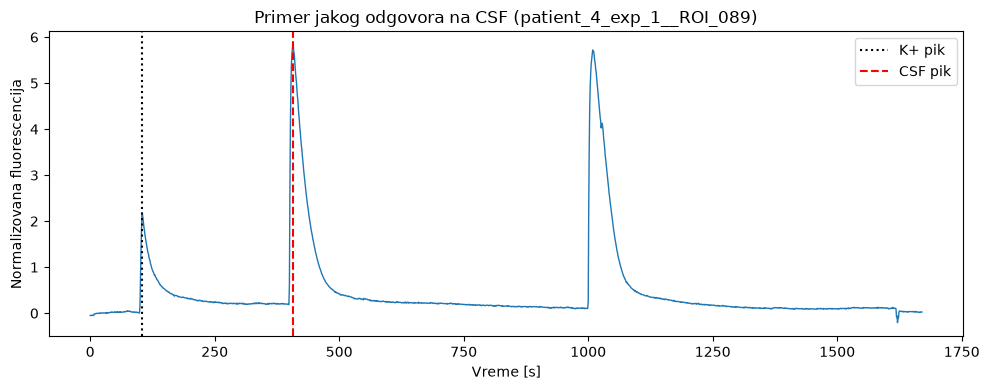

In [28]:
# 4 (ALS)
plot_roi_trace(
    strong_als_responder,
    title=(
        "Primer jakog odgovora na CSF "
        f"({strong_als_responder['record_id']})"
    ),
)

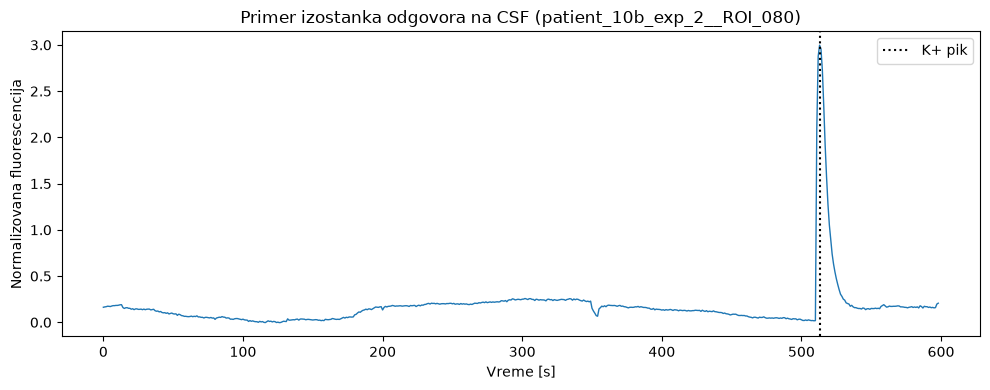

In [29]:
# 10b (SMA)
plot_roi_trace(
    sma_10b_nonresponder,
    title=(
        "Primer izostanka odgovora na CSF "
        f"({sma_10b_nonresponder['record_id']})"
    ),
)

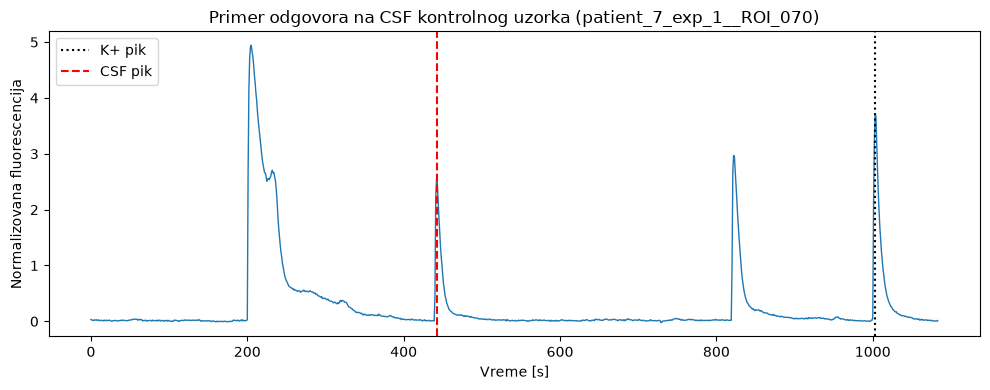

In [30]:
# 7 (kontrola)
plot_roi_trace(
    control_responder,
    title=(
        "Primer odgovora na CSF kontrolnog uzorka "
        f"({control_responder['record_id']})"
    ),
)

Sada imamo i vizuelizaciju fluorescentnih signala tokom vremena. Primećujemo da ima varijabilnosti u intenzitetima odgovora na različite tretmane među ćelijama, ali i u istim ćelijama.

Možemo ispitati i neke dodatne osobine podataka; na primer, odnos intenziteta odgovora na CSF i K<sup>+</sup>, kao i odnos integrala ova dva odgovora.

In [31]:
df["csf_to_k_amplitude_ratio"] = (
    df["csf_amplitude"] / df["k_ref_amplitude"]
)

df["csf_to_k_integral_ratio"] = (
    df["csf_integral"] / df["k_ref_integral"]
)

ratio_columns = [
    "csf_to_k_amplitude_ratio",
    "csf_to_k_integral_ratio",
]

# Osiguravanje od beskonačnih vrednosti
df[ratio_columns] = df[ratio_columns].replace(
    [np.inf, -np.inf],
    np.nan,
)

Za modeliranje bi nam moglo biti korisno da napravimo binarne brojčane verzije `csf_response_detected` i `csf_multiple_responses` promenljivih.

In [32]:
df["csf_response_detected_int"] = (
    df["csf_response_detected"].astype(int)
)

df["csf_multiple_responses_int"] = (
    df["csf_multiple_responses"].astype(int)
)

In [33]:
# Provera novih promenljivih
df[
    [
        "k_ref_amplitude",
        "csf_amplitude",
        "csf_to_k_amplitude_ratio",
        "k_ref_integral",
        "csf_integral",
        "csf_to_k_integral_ratio",
        "csf_response_detected_int",
        "csf_peak_count",
    ]
].describe()

,k_ref_amplitude,csf_amplitude,csf_to_k_amplitude_ratio,k_ref_integral,csf_integral,csf_to_k_integral_ratio,csf_response_detected_int,csf_peak_count
count,996.000000,675.000000,674.000000,997.000000,997.000000,997.000000,997.000000,997.000000
mean,3.028369,2.343360,0.907888,55.867435,56.601458,1.290962,0.677031,0.757272
std,1.454420,1.249100,0.684178,35.197248,69.478189,1.715382,0.467846,0.730338
min,0.134997,0.118894,0.027603,2.216463,-2.031476,-0.062626,0.000000,0.000000
25%,1.922553,1.357321,0.539203,31.858694,5.914426,0.132908,0.000000,0.000000
50%,2.928866,2.540392,0.762280,46.784940,33.156245,0.599132,1.000000,1.000000
75%,4.056623,3.281109,1.095812,68.673092,75.005652,1.758588,1.000000,1.000000
max,7.052302,5.824514,8.319118,238.052994,451.476410,13.635137,1.000000,10.000000


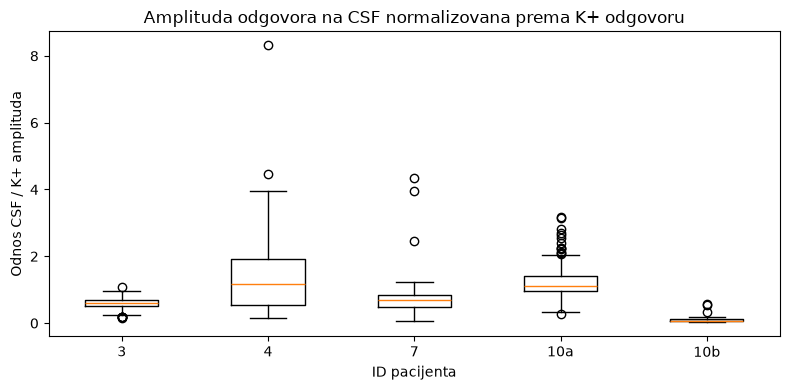

In [34]:
# Odnos amplituda CSF/K+ odgovora po pacijentu
plt.figure(figsize=(8, 4))

patient_order = ["3", "4", "7", "10a", "10b"]

data_to_plot = [
    df.loc[
        df["patient_id"].astype(str) == patient_id,
        "csf_to_k_amplitude_ratio",
    ].dropna()
    for patient_id in patient_order
]

plt.boxplot(data_to_plot, tick_labels=patient_order)
plt.xlabel("ID pacijenta")
plt.ylabel("Odnos CSF / K+ amplituda")
plt.title("Amplituda odgovora na CSF normalizovana prema K+ odgovoru")
plt.tight_layout()
plt.show()

Odnos amplituda može biti koristan prilikom analize. U tabeli iznad vidimo da je medijalna CSF amplituda jednaka približno 3/4 referentne K+ amplitude. Međutim, maksimalna vrednost od `8.32` je neobična - ona može biti rezultat neobično male K+ amplitude ili zaista veoma visoke CSF amplitude (ili kombinacije ova dva faktora). Izvršićemo pregled najviših vrednosti.

In [35]:
amplitude_ratio_outliers = (
    df
    .nlargest(15, "csf_to_k_amplitude_ratio")
    [
        [
            "record_id",
            "experiment_id",
            "patient_id",
            "class_label",
            "k_ref_amplitude",
            "csf_amplitude",
            "csf_to_k_amplitude_ratio",
        ]
    ]
)

amplitude_ratio_outliers

,record_id,experiment_id,patient_id,class_label,k_ref_amplitude,csf_amplitude,csf_to_k_amplitude_ratio
751,patient_4_exp_1__ROI_057,patient_4_exp_1,4,ALS,0.271744,2.260673,8.319118
793,patient_4_exp_1__ROI_106,patient_4_exp_1,4,ALS,0.307759,1.374668,4.466697
861,patient_7_exp_1__ROI_048,patient_7_exp_1,7,Control,0.672182,2.914987,4.336603
862,patient_7_exp_1__ROI_049,patient_7_exp_1,7,Control,0.797804,3.165772,3.968106
745,patient_4_exp_1__ROI_051,patient_4_exp_1,4,ALS,0.869558,3.430578,3.945197
787,patient_4_exp_1__ROI_099,patient_4_exp_1,4,ALS,0.609594,2.362912,3.876209
719,patient_4_exp_1__ROI_021,patient_4_exp_1,4,ALS,0.761164,2.573858,3.381477
732,patient_4_exp_1__ROI_038,patient_4_exp_1,4,ALS,1.158429,3.762991,3.248357
12,patient_10a_exp_1__ROI_014,patient_10a_exp_1,10a,SMA,1.565270,4.962975,3.170683
15,patient_10a_exp_1__ROI_017,patient_10a_exp_1,10a,SMA,1.511272,4.739853,3.136333


In [36]:
df.groupby(
    "experiment_id"
)["csf_to_k_amplitude_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
experiment_id,,,,,,,,
patient_10a_exp_1,215.0,1.215762,0.481387,0.283635,0.962689,1.103244,1.403880,3.170683
patient_10b_exp_1,11.0,0.086929,0.044691,0.037723,0.053203,0.072912,0.109491,0.168507
patient_10b_exp_2,23.0,0.133295,0.151520,0.027603,0.058361,0.072807,0.149310,0.577865
patient_3_exp_1,147.0,0.591576,0.171243,0.150393,0.504407,0.612185,0.700916,1.081423
patient_4_exp_1,97.0,1.383295,1.184177,0.154643,0.534432,1.165350,1.907495,8.319118
patient_7_exp_1,181.0,0.692622,0.467880,0.056540,0.475972,0.690803,0.827710,4.336603


Veliki odnosi amplituda su, izgleda, izazvani primarno malim K+ amplitudama, najviše u slučaju pacijenta `4`. Ništa ne ukazuje na to da su u pitanju greške, pa ove vrednosti svakako neće biti odbačene.

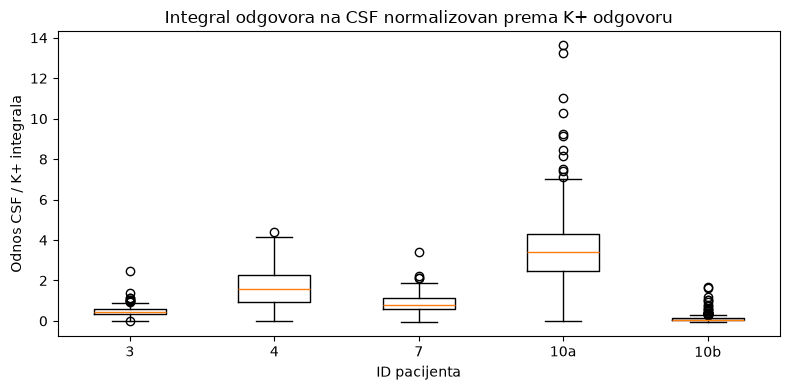

In [37]:
# Odnos integrala CSF/K+ odgovora po pacijentu
plt.figure(figsize=(8, 4))

patient_order = ["3", "4", "7", "10a", "10b"]

data_to_plot = [
    df.loc[
        df["patient_id"].astype(str) == patient_id,
        "csf_to_k_integral_ratio",
    ].dropna()
    for patient_id in patient_order
]

plt.boxplot(data_to_plot, tick_labels=patient_order)
plt.xlabel("ID pacijenta")
plt.ylabel("Odnos CSF / K+ integrala")
plt.title("Integral odgovora na CSF normalizovan prema K+ odgovoru")
plt.tight_layout()
plt.show()

Kada je u pitanju odnos integrala, primećujemo da je srednja vrednost više nego dvostruko veća od medijalne, što pokazuje veliki uticaj određenih visokih vrednosti. Osim toga, ova osobina se razlikuje od odnosa amplituda iz nekoliko razloga:
- Odnos amplituda postoji samo za detektovane CSF pikove, dok odnos integrala postoji za sve;
- S tim u vezi, CSF integral može obuhvatati šum i druge, biološki neznačajne promene u intenzitetu fluorescencije;
- Vremenski periodi integrala razlikuju se u zavisnosti od eksperimenta.

Stoga, `csf_to_k_integral_ratio` je promenljiva koja je potencijalno korisna u analizama, ali je važno imati na umu da njena vrednost uveliko zavisi od načina na koji su obrađeni podaci datog eksperimenta.

Možemo malo detaljnije ispitati ovu promenljivu.

In [38]:
df.groupby(
    "csf_response_detected"
)["csf_to_k_integral_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
csf_response_detected,,,,,,,,
False,322.0,0.154546,0.295237,-0.056248,0.026722,0.063769,0.146143,2.546719
True,675.0,1.833075,1.842689,-0.062626,0.540459,1.081689,2.840635,13.635137


In [39]:
df.groupby(
    "experiment_id"
)["csf_to_k_integral_ratio"].describe()

,count,mean,std,min,25%,50%,75%,max
experiment_id,,,,,,,,
patient_10a_exp_1,230.0,3.623059,2.031601,0.000000,2.461870,3.417474,4.294727,13.635137
patient_10b_exp_1,171.0,0.044610,0.038489,-0.056248,0.019356,0.036439,0.061065,0.195935
patient_10b_exp_2,144.0,0.212943,0.265172,-0.013425,0.074566,0.134878,0.256546,1.696344
patient_3_exp_1,163.0,0.480463,0.264572,-0.015503,0.346882,0.448555,0.587945,2.456016
patient_4_exp_1,106.0,1.646062,0.922502,0.000000,0.938999,1.585785,2.259715,4.394512
patient_7_exp_1,183.0,0.889046,0.472974,-0.062626,0.583774,0.808071,1.111066,3.427956


In [40]:
integral_ratio_outliers = (
    df
    .nlargest(15, "csf_to_k_integral_ratio")
    [
        [
            "record_id",
            "experiment_id",
            "patient_id",
            "class_label",
            "csf_response_detected",
            "k_ref_integral",
            "csf_integral",
            "csf_to_k_integral_ratio",
        ]
    ]
)

integral_ratio_outliers

,record_id,experiment_id,patient_id,class_label,csf_response_detected,k_ref_integral,csf_integral,csf_to_k_integral_ratio
15,patient_10a_exp_1__ROI_017,patient_10a_exp_1,10a,SMA,True,18.722564,255.284737,13.635137
12,patient_10a_exp_1__ROI_014,patient_10a_exp_1,10a,SMA,True,23.157607,306.871433,13.251431
214,patient_10a_exp_1__ROI_227,patient_10a_exp_1,10a,SMA,True,6.521577,71.843356,11.016255
4,patient_10a_exp_1__ROI_006,patient_10a_exp_1,10a,SMA,True,24.171942,248.130689,10.265236
123,patient_10a_exp_1__ROI_129,patient_10a_exp_1,10a,SMA,True,22.231422,205.153443,9.228084
10,patient_10a_exp_1__ROI_012,patient_10a_exp_1,10a,SMA,True,31.469152,287.845026,9.146895
9,patient_10a_exp_1__ROI_011,patient_10a_exp_1,10a,SMA,True,33.800176,285.460912,8.445545
220,patient_10a_exp_1__ROI_234,patient_10a_exp_1,10a,SMA,True,14.414790,117.634210,8.160661
128,patient_10a_exp_1__ROI_135,patient_10a_exp_1,10a,SMA,True,12.615255,94.913936,7.523743
11,patient_10a_exp_1__ROI_013,patient_10a_exp_1,10a,SMA,True,47.882634,355.783041,7.430315


Najveći odnosi integrala potiču od pacijenta `10a`. Ovo ide u prilog prethodnoj primedbi da je ova promenljiva uveliko zavisna od vremenskog perioda za koji je integral odgovora na K+ i/ili CSF računat u datom eksperimentu.

Sada ćemo još jednom proveriti stope odgovora na CSF, ali ovaj put na nivou pacijenta.

In [41]:
patient_response_rates = (
    df
    .groupby(["patient_id", "class_label"], dropna=False)
    .agg(
        n_rois=("record_id", "count"),
        csf_responses=("csf_response_detected", "sum"),
    )
    .reset_index()
)

patient_response_rates["csf_response_rate"] = (
    patient_response_rates["csf_responses"]
    / patient_response_rates["n_rois"]
)

patient_response_rates

,patient_id,class_label,n_rois,csf_responses,csf_response_rate
0,10a,SMA,230,216,0.939130
1,10b,SMA,315,34,0.107937
2,3,ALS,163,147,0.901840
3,4,ALS,106,97,0.915094
4,7,Control,183,181,0.989071


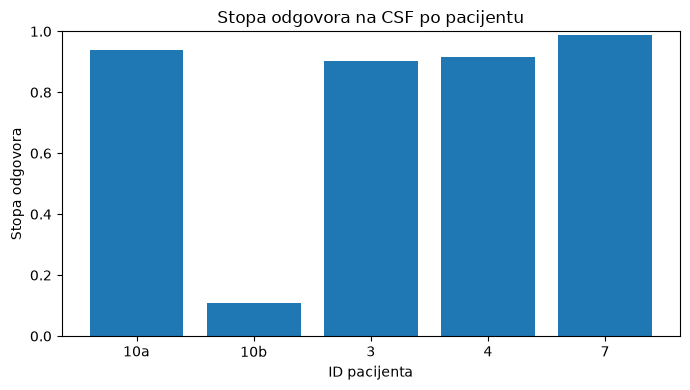

In [42]:
# Vizuelizacija
plt.figure(figsize=(7, 4))
plt.bar(
    patient_response_rates["patient_id"].astype(str),
    patient_response_rates["csf_response_rate"],
)

plt.xlabel("ID pacijenta")
plt.ylabel("Stopa odgovora")
plt.title("Stopa odgovora na CSF po pacijentu")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

Stopa odgovora na CSF je ono što, prema onome što smo dosad videli, najbolje razdvaja različite fenotipove. Zanimljivo je da tretman CSF-a kontrole rezultuje veoma visokom stopom odgovora, kao i da CSF poreklom od pacijenta `10b` rezultuje veoma niskom stopom odgovora, iako su neuroni u eksperimentima bili vijabilni i pouzdano pokazivali odgovor na K+. 

Međutim, ono što je neobično je da u slučaju pacijenta `10a`, iako ima isti neurodegenerativni fenotip kao pacijent `10b` (SMA), ne primećujemo nisku stopu odgovora na CSF, te očigledno ne možemo zaključiti da je rezultat sa CSF-om pacijenta 10b isključivo posledica prisustva SMA.

Sada možemo izdvojiti neke od numeričkih kolona za koje ćemo izračunati korelaciju.

In [43]:
eda_numeric_columns = [
    "k_ref_amplitude",
    "k_ref_half_width",
    "k_ref_integral",

    "csf_response_detected_int",
    "csf_peak_count",
    "csf_amplitude",
    "csf_half_width",
    "csf_integral",

    "csf_to_k_amplitude_ratio",
    "csf_to_k_integral_ratio",
]

corr = df[eda_numeric_columns].corr(method="spearman")

corr

,k_ref_amplitude,k_ref_half_width,k_ref_integral,csf_response_detected_int,csf_peak_count,csf_amplitude,csf_half_width,csf_integral,csf_to_k_amplitude_ratio,csf_to_k_integral_ratio
k_ref_amplitude,1.000000,0.021878,0.728617,0.002382,-0.005792,0.443324,-0.545121,-0.042214,-0.376779,-0.324516
k_ref_half_width,0.021878,1.000000,0.560128,0.085274,0.071226,0.096649,0.357745,0.201246,0.020915,-0.035862
k_ref_integral,0.728617,0.560128,1.000000,0.032159,0.020350,0.422784,-0.123599,0.112650,-0.195629,-0.277536
csf_response_detected_int,0.002382,0.085274,0.032159,1.000000,0.959338,NaN,NaN,0.766306,NaN,0.733573
csf_peak_count,-0.005792,0.071226,0.020350,0.959338,1.000000,-0.017933,-0.045714,0.739649,0.020265,0.714449
csf_amplitude,0.443324,0.096649,0.422784,NaN,-0.017933,1.000000,-0.046306,0.657458,0.564480,0.308822
csf_half_width,-0.545121,0.357745,-0.123599,NaN,-0.045714,-0.046306,1.000000,0.610547,0.398871,0.629419
csf_integral,-0.042214,0.201246,0.112650,0.766306,0.739649,0.657458,0.610547,1.000000,0.741857,0.902854
csf_to_k_amplitude_ratio,-0.376779,0.020915,-0.195629,NaN,0.020265,0.564480,0.398871,0.741857,1.000000,0.806360
csf_to_k_integral_ratio,-0.324516,-0.035862,-0.277536,0.733573,0.714449,0.308822,0.629419,0.902854,0.806360,1.000000


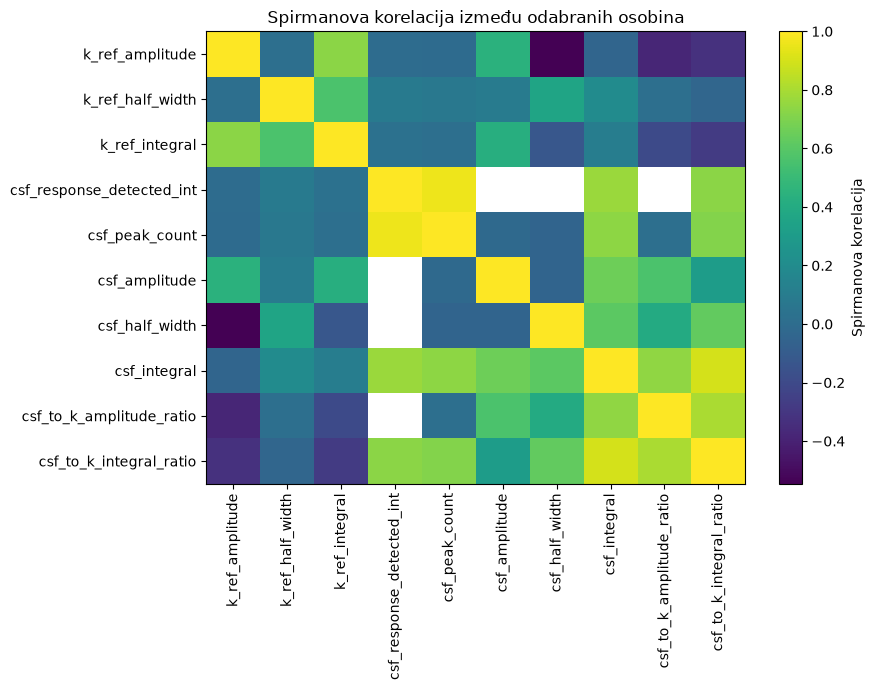

In [44]:
# Vizuelizacija
plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar(label="Spirmanova korelacija")

plt.xticks(
    ticks=np.arange(len(corr.columns)),
    labels=corr.columns,
    rotation=90,
)

plt.yticks(
    ticks=np.arange(len(corr.index)),
    labels=corr.index,
)

plt.title("Spirmanova korelacija između odabranih osobina")
plt.tight_layout()
plt.show()

Neke od korelacija su očekivane i biološki smislene:
- `k_ref_amplitude` i `k_ref_integral`: `0.729`. Veći pikovi obično podrazumevaju veći ukupan odgovor.
- `k_ref_half_width` i `k_ref_integral`: `0.560`. Odgovori koji su "široki" će uglavnom imati veći ukupan intenzitet.
- `csf_amplitude` i `csf_integral`: `0.657`. Isti slučaj kao i za K+.
- `csf_half_width` i `csf_integral`: `0.611`. Ponovo, isto objašnjenje.

Neke od promenljivih su, ipak, visoko povezane i mogu se okarakterisati kao redundantne.
- `csf_response_detected_int` i `csf_peak_count`: `0.959`. Ćelije koje ne odgovaraju imaju `csf_peak_count = 0`, a one koje odgovaraju imaju `1` ili više odgovora. Osim toga, `csf_peak_count` je u pozitivnoj korelaciji sa promenljivim poput `csf_integral`, što je ponovo sasvim očekivano i ne pruža naročito korisnu informaciju. 
- `csf_integral` i `csf_to_k_integral_ratio`: `0.903`. Među CSF integralima je prisutna mnogo veća varijabilnost, pa tako veća vrednost integrala generalno povlači i veću razliku u odnosu na K+ integral.
- `csf_to_k_amplitude_ratio` i `csf_to_k_integral_ratio`: `0.806`. Slično kao gore.

Korelaciju možemo izračunati i na drugačiji način: prvo koristeći osobine koje imaju svi ROI, a zatim koristeći one osobine koje su karakteristične samo za ćelije koje odgovaraju na CSF.

In [45]:
# Svi ROI-evi
all_roi_correlation_features = [
    "k_ref_amplitude",
    "k_ref_half_width",
    "k_ref_integral",
    "csf_response_detected_int",
    "csf_peak_count",
    "csf_integral",
    "csf_to_k_integral_ratio",
]

all_roi_corr = df[
    all_roi_correlation_features
].corr(method="spearman")

all_roi_corr

,k_ref_amplitude,k_ref_half_width,k_ref_integral,csf_response_detected_int,csf_peak_count,csf_integral,csf_to_k_integral_ratio
k_ref_amplitude,1.000000,0.021878,0.728617,0.002382,-0.005792,-0.042214,-0.324516
k_ref_half_width,0.021878,1.000000,0.560128,0.085274,0.071226,0.201246,-0.035862
k_ref_integral,0.728617,0.560128,1.000000,0.032159,0.020350,0.112650,-0.277536
csf_response_detected_int,0.002382,0.085274,0.032159,1.000000,0.959338,0.766306,0.733573
csf_peak_count,-0.005792,0.071226,0.020350,0.959338,1.000000,0.739649,0.714449
csf_integral,-0.042214,0.201246,0.112650,0.766306,0.739649,1.000000,0.902854
csf_to_k_integral_ratio,-0.324516,-0.035862,-0.277536,0.733573,0.714449,0.902854,1.000000


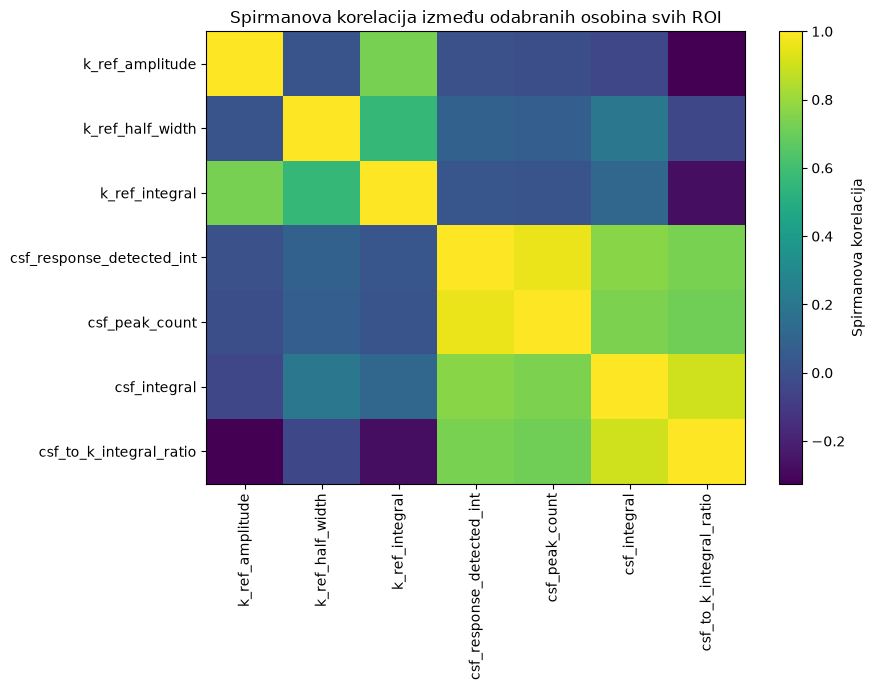

In [46]:
# Vizuelizacija
plt.figure(figsize=(9, 7))
plt.imshow(all_roi_corr, aspect="auto")
plt.colorbar(label="Spirmanova korelacija")

plt.xticks(
    ticks=np.arange(len(all_roi_corr.columns)),
    labels=all_roi_corr.columns,
    rotation=90,
)

plt.yticks(
    ticks=np.arange(len(all_roi_corr.index)),
    labels=all_roi_corr.index,
)

plt.title("Spirmanova korelacija između odabranih osobina svih ROI")
plt.tight_layout()
plt.show()

In [47]:
# ROI s odgovorom na CSF
responder_correlation_features = [
    "k_ref_amplitude",
    "k_ref_half_width",
    "k_ref_integral",
    "csf_amplitude",
    "csf_half_width",
    "csf_integral",
    "csf_to_k_amplitude_ratio",
    "csf_to_k_integral_ratio",
]

responder_corr = (
    df.loc[df["csf_response_detected"]]
    [responder_correlation_features]
    .corr(method="spearman")
)

responder_corr

,k_ref_amplitude,k_ref_half_width,k_ref_integral,csf_amplitude,csf_half_width,csf_integral,csf_to_k_amplitude_ratio,csf_to_k_integral_ratio
k_ref_amplitude,1.000000,0.009759,0.713695,0.443324,-0.545121,-0.062565,-0.376779,-0.514833
k_ref_half_width,0.009759,1.000000,0.591837,0.096649,0.357745,0.239745,0.020915,-0.166874
k_ref_integral,0.713695,0.591837,1.000000,0.422784,-0.123599,0.205797,-0.195629,-0.441794
csf_amplitude,0.443324,0.096649,0.422784,1.000000,-0.046306,0.657458,0.564480,0.308822
csf_half_width,-0.545121,0.357745,-0.123599,-0.046306,1.000000,0.610547,0.398871,0.629419
csf_integral,-0.062565,0.239745,0.205797,0.657458,0.610547,1.000000,0.741857,0.754798
csf_to_k_amplitude_ratio,-0.376779,0.020915,-0.195629,0.564480,0.398871,0.741857,1.000000,0.806360
csf_to_k_integral_ratio,-0.514833,-0.166874,-0.441794,0.308822,0.629419,0.754798,0.806360,1.000000


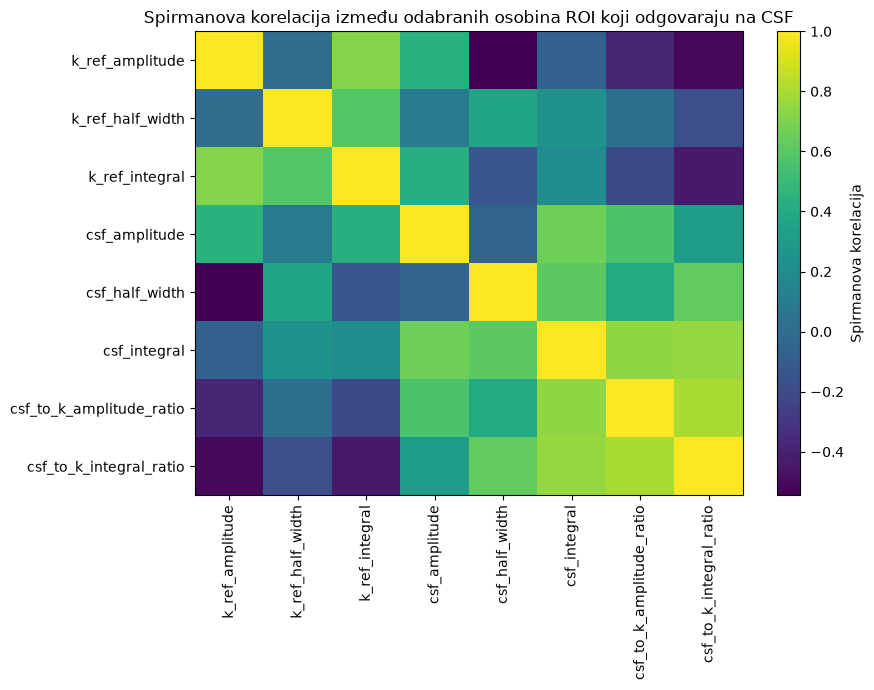

In [48]:
# Vizuelizacija
plt.figure(figsize=(9, 7))
plt.imshow(responder_corr, aspect="auto")
plt.colorbar(label="Spirmanova korelacija")

plt.xticks(
    ticks=np.arange(len(responder_corr.columns)),
    labels=responder_corr.columns,
    rotation=90,
)

plt.yticks(
    ticks=np.arange(len(responder_corr.index)),
    labels=responder_corr.index,
)

plt.title("Spirmanova korelacija između odabranih osobina ROI koji odgovaraju na CSF")
plt.tight_layout()
plt.show()

### Parametri fita 

Sada ćemo detaljnije pregledati vrednosti koje se tiču fitovane jednačine raspada kalcijumskog talasa tokom vremena.

In [49]:
# Definisanje grupa prediktora
k_fit_features = [
    "k_ref_free_coef",
    "k_ref_coef_fast",
    "k_ref_tau_fast",
    "k_ref_coef_slow",
    "k_ref_tau_slow",
    "k_ref_gof",
    "k_ref_percent_fast",
]

csf_fit_features = [
    "csf_free_coef",
    "csf_coef_fast",
    "csf_tau_fast",
    "csf_coef_slow",
    "csf_tau_slow",
    "csf_gof",
    "csf_percent_fast",
]

fit_features = [
    *k_fit_features,
    *csf_fit_features,
]

In [50]:
# Dostupnost i validnost fita za svaki eksperiment
fit_status_summary = (
    df
    .groupby(
        [
            "experiment_id",
            "patient_id",
            "class_label",
        ]
    )
    .agg(
        n_rois=("record_id", "count"),
        k_fit_available=("k_ref_fit_available", "sum"),
        k_fit_valid=("k_ref_fit_valid", "sum"),
        csf_fit_available=("csf_fit_available", "sum"),
        csf_fit_valid=("csf_fit_valid", "sum"),
    )
    .reset_index()
)

fit_status_summary["k_fit_valid_rate"] = (
    fit_status_summary["k_fit_valid"]
    / fit_status_summary["n_rois"]
)

fit_status_summary["csf_fit_valid_rate"] = (
    fit_status_summary["csf_fit_valid"]
    / fit_status_summary["n_rois"]
)

fit_status_summary

,experiment_id,patient_id,class_label,n_rois,k_fit_available,k_fit_valid,csf_fit_available,csf_fit_valid,k_fit_valid_rate,csf_fit_valid_rate
0,patient_10a_exp_1,10a,SMA,230,228,227,217,214,0.986957,0.930435
1,patient_10b_exp_1,10b,SMA,171,170,161,19,10,0.941520,0.058480
2,patient_10b_exp_2,10b,SMA,144,143,140,25,22,0.972222,0.152778
3,patient_3_exp_1,3,ALS,163,162,161,148,146,0.987730,0.895706
4,patient_4_exp_1,4,ALS,106,105,103,98,95,0.971698,0.896226
5,patient_7_exp_1,7,Control,183,182,181,181,179,0.989071,0.978142


In [51]:
# Provera dostupnosti fita i prisustva odgovora na CSF
pd.crosstab(
    df["csf_response_detected"],
    df["csf_fit_valid"],
    margins=True,
)

csf_fit_valid,False,True,All
csf_response_detected,,,
False,322,0,322
True,9,666,675
All,331,666,997


In [52]:
# Nedostajuće vrednosti za svaki parametar
fit_missingness = (
    df[fit_features]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame(name="missing_fraction")
)

fit_missingness

,missing_fraction
csf_tau_slow,0.331996
csf_gof,0.331996
csf_coef_slow,0.331996
csf_tau_fast,0.331996
csf_coef_fast,0.331996
csf_free_coef,0.331996
csf_percent_fast,0.331996
k_ref_tau_slow,0.024072
k_ref_gof,0.024072
k_ref_tau_fast,0.024072


In [53]:
# Nedostajuće vrednosti po eksperimentu
fit_missingness_by_experiment = (
    df
    .groupby("experiment_id")[fit_features]
    .apply(lambda group: group.isna().mean())
)

fit_missingness_by_experiment

,k_ref_free_coef,k_ref_coef_fast,k_ref_tau_fast,k_ref_coef_slow,k_ref_tau_slow,k_ref_gof,k_ref_percent_fast,csf_free_coef,csf_coef_fast,csf_tau_fast,csf_coef_slow,csf_tau_slow,csf_gof,csf_percent_fast
experiment_id,,,,,,,,,,,,,,
patient_10a_exp_1,0.013043,0.013043,0.013043,0.013043,0.013043,0.013043,0.013043,0.069565,0.069565,0.069565,0.069565,0.069565,0.069565,0.069565
patient_10b_exp_1,0.058480,0.058480,0.058480,0.058480,0.058480,0.058480,0.058480,0.941520,0.941520,0.941520,0.941520,0.941520,0.941520,0.941520
patient_10b_exp_2,0.027778,0.027778,0.027778,0.027778,0.027778,0.027778,0.027778,0.847222,0.847222,0.847222,0.847222,0.847222,0.847222,0.847222
patient_3_exp_1,0.012270,0.012270,0.012270,0.012270,0.012270,0.012270,0.012270,0.104294,0.104294,0.104294,0.104294,0.104294,0.104294,0.104294
patient_4_exp_1,0.028302,0.028302,0.028302,0.028302,0.028302,0.028302,0.028302,0.103774,0.103774,0.103774,0.103774,0.103774,0.103774,0.103774
patient_7_exp_1,0.010929,0.010929,0.010929,0.010929,0.010929,0.010929,0.010929,0.021858,0.021858,0.021858,0.021858,0.021858,0.021858,0.021858


Vidimo da je većina nedostajućih vrednosti iz eksperimenata sa pacijentom `10b`, naročito onih vezanih za CSF odgovor. 

In [54]:
# Ispitivanje opsega vrednosti
fit_descriptive_statistics = (
    df[fit_features]
    .describe()
    .T
)

fit_descriptive_statistics

,count,mean,std,min,25%,50%,75%,max
k_ref_free_coef,973.0,0.039359,0.067755,2.220946e-14,1.396858e-08,0.002476,0.061877,0.651000
k_ref_coef_fast,973.0,2.951556,1.505669,1.326851e-01,1.709919e+00,2.863308,4.111495,7.462661
k_ref_tau_fast,973.0,10.890932,4.046097,4.166937e+00,8.093534e+00,10.012676,12.702105,41.529526
k_ref_coef_slow,973.0,0.165564,0.262582,2.402737e-14,2.835211e-03,0.088983,0.215534,2.623642
k_ref_tau_slow,973.0,348.569924,1033.348403,1.000000e+02,1.000000e+02,100.291214,114.180495,15854.738802
k_ref_gof,973.0,0.993455,0.027189,2.542093e-01,9.935583e-01,0.996943,0.998725,0.999868
k_ref_percent_fast,973.0,0.934312,0.084444,4.018988e-01,8.985143e-01,0.962952,0.999076,1.000000
csf_free_coef,666.0,0.052086,0.085287,5.105351e-14,3.154317e-05,0.018892,0.066050,0.622579
csf_coef_fast,666.0,2.522417,1.393231,4.584525e-10,1.470785e+00,2.780729,3.540392,6.066628
csf_tau_fast,666.0,21.675379,16.575088,1.000050e+00,8.982502e+00,14.808422,30.338705,100.000000


In [55]:
# Dodavanje medijalne vrednosti i mere asimetričnosti
fit_descriptive_statistics["median"] = (
    df[fit_features].median()
)

fit_descriptive_statistics["skewness"] = (
    df[fit_features].skew()
)

fit_descriptive_statistics[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "median",
        "75%",
        "max",
        "skewness",
    ]
]

,count,mean,std,min,25%,median,75%,max,skewness
k_ref_free_coef,973.0,0.039359,0.067755,2.220946e-14,1.396858e-08,0.002476,0.061877,0.651000,3.278681
k_ref_coef_fast,973.0,2.951556,1.505669,1.326851e-01,1.709919e+00,2.863308,4.111495,7.462661,0.261158
k_ref_tau_fast,973.0,10.890932,4.046097,4.166937e+00,8.093534e+00,10.012676,12.702105,41.529526,1.746735
k_ref_coef_slow,973.0,0.165564,0.262582,2.402737e-14,2.835211e-03,0.088983,0.215534,2.623642,3.881979
k_ref_tau_slow,973.0,348.569924,1033.348403,1.000000e+02,1.000000e+02,100.291214,114.180495,15854.738802,7.196728
k_ref_gof,973.0,0.993455,0.027189,2.542093e-01,9.935583e-01,0.996943,0.998725,0.999868,-22.574317
k_ref_percent_fast,973.0,0.934312,0.084444,4.018988e-01,8.985143e-01,0.962952,0.999076,1.000000,-1.954207
csf_free_coef,666.0,0.052086,0.085287,5.105351e-14,3.154317e-05,0.018892,0.066050,0.622579,3.005795
csf_coef_fast,666.0,2.522417,1.393231,4.584525e-10,1.470785e+00,2.780729,3.540392,6.066628,-0.211890
csf_tau_fast,666.0,21.675379,16.575088,1.000050e+00,8.982502e+00,14.808422,30.338705,100.000000,1.446502


Vidimo da je vrednost koeficijenta uz "spori" član naročito mala, tako da brza komponenta dominira u većini slučajeva, tako da je bieksponencijalni fit u stvari ekvivalentan: 

\begin{equation}
    y(t) \approx a + b e^{-t/\tau_f}
\end{equation}

Ovo verovatno znači da raspad kalcijumskog odgovora uglavnom odgovara brzoj komponenti fita. Kao posledica toga, prediktori `coef_slow`, `tau_slow` i `% fast` mogu biti relativno nestabilni i/ili nedovoljno informativni za većinu ROI-eva.

Osim toga, `k_ref_tau_slow` i `csf_tau_slow` imaju minimalne i medijalne vrednosti blizu `100`, dok su im maksimumi vrlo visoki. Verovatno se radi o tome da je `100` ograničenje koje je bilo zadato prilikom fitovanja. Takođe, budući i da je koeficijent uz spori član uglavnom veoma blizu nuli, vrednosti vremenske konstante može dramatično varirati bez značajnog efekta na ukupnu vrednost člana, a time i celog fita. Stoga, spora vremenska konstanta ne može se interpretirati kao pouzdana mera dinamike kalcijuma.

In [56]:
# Provera beskonačnih vrednosti
np.isinf(
    df[fit_features].to_numpy(dtype=float)
).sum()

np.int64(0)

In [57]:
# Provera vremenskih konstanti (moraju biti pozitivne)
tau_columns = [
    "k_ref_tau_fast",
    "k_ref_tau_slow",
    "csf_tau_fast",
    "csf_tau_slow",
]

for column in tau_columns:
    print(
        column,
        "negativno:",
        (df[column] <= 0).sum(),
    )

k_ref_tau_fast negativno: 0
k_ref_tau_slow negativno: 0
csf_tau_fast negativno: 0
csf_tau_slow negativno: 0


In [58]:
# Provera validnosti %fast vrednosti
for column in [
    "k_ref_percent_fast",
    "csf_percent_fast",
]:
    print(
        column,
        "izvan validnog opsega:",
        ((df[column] < 0) | (df[column] > 1)).sum(),
    )

k_ref_percent_fast izvan validnog opsega: 0
csf_percent_fast izvan validnog opsega: 0


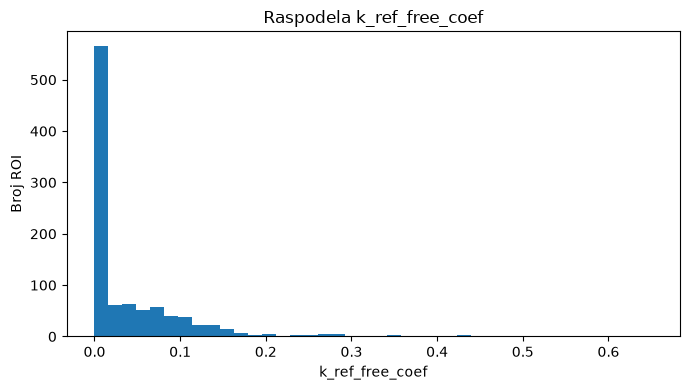

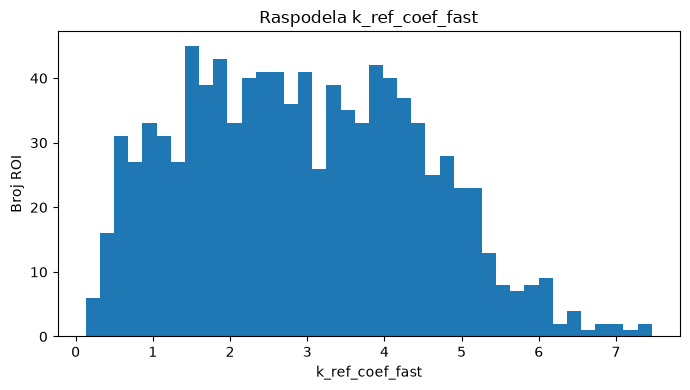

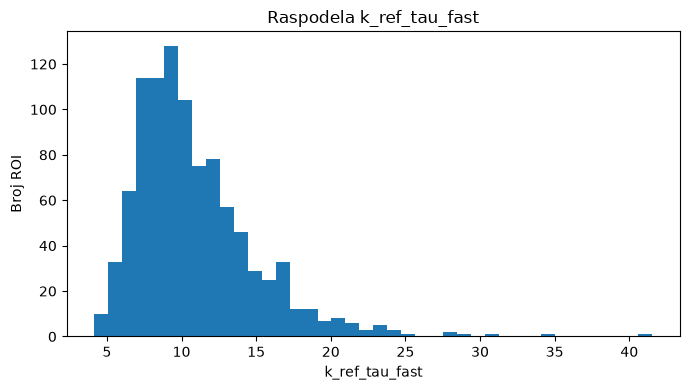

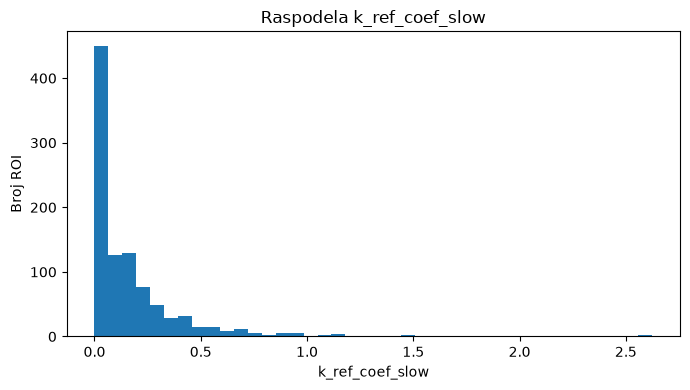

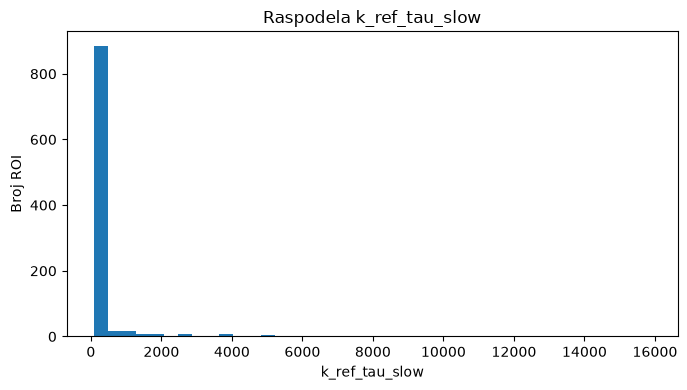

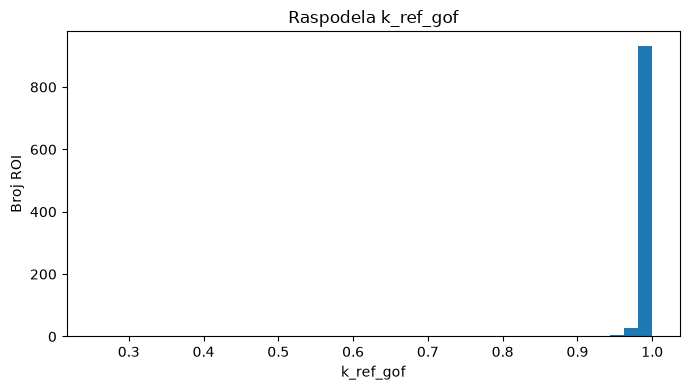

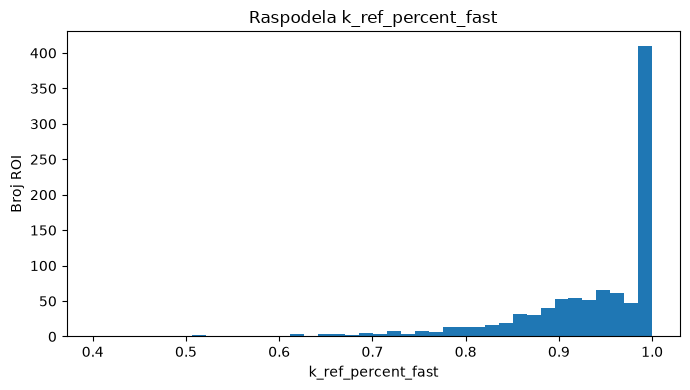

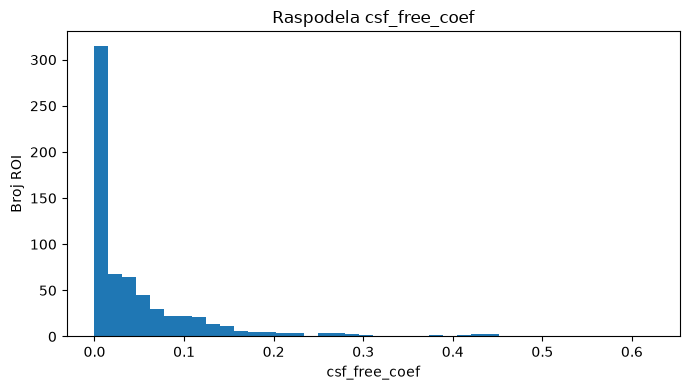

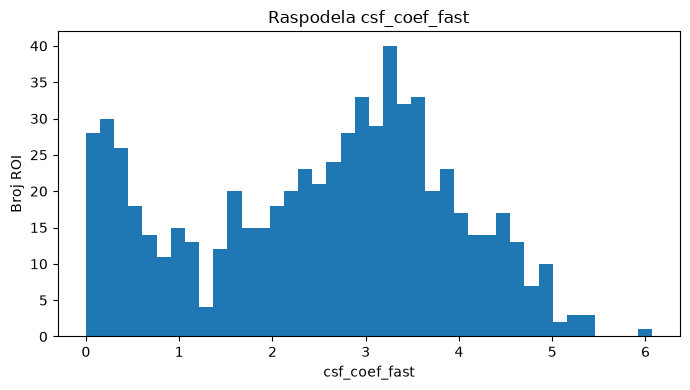

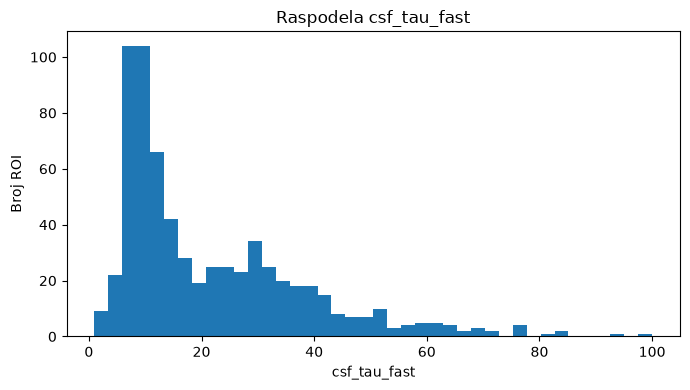

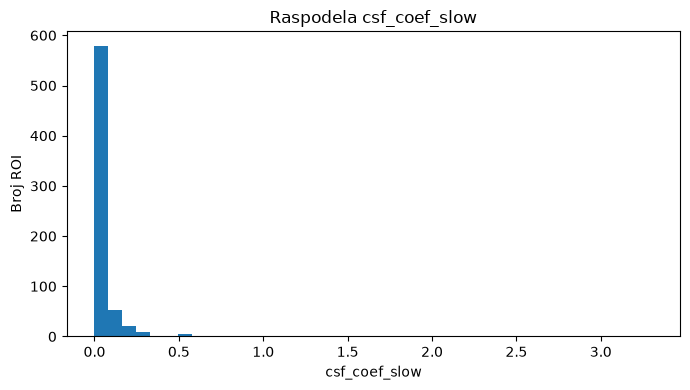

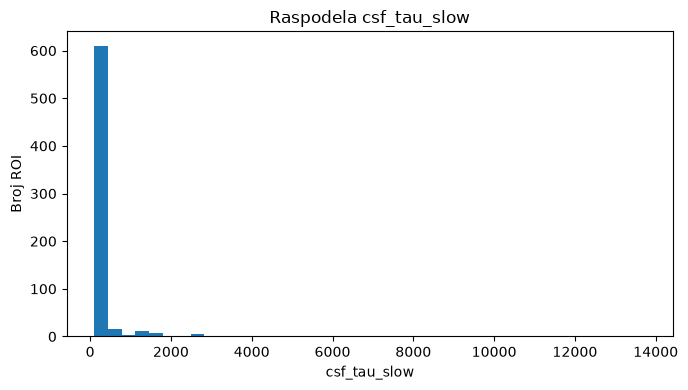

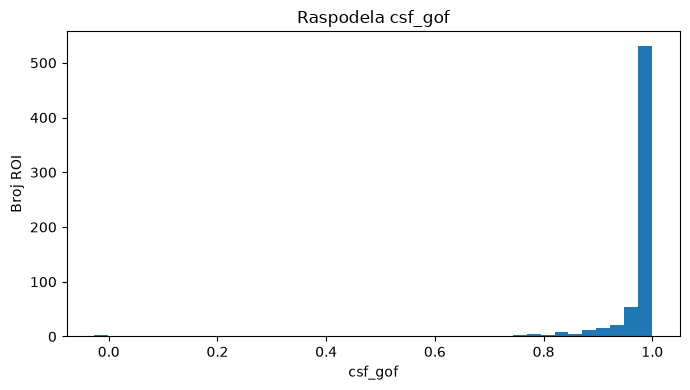

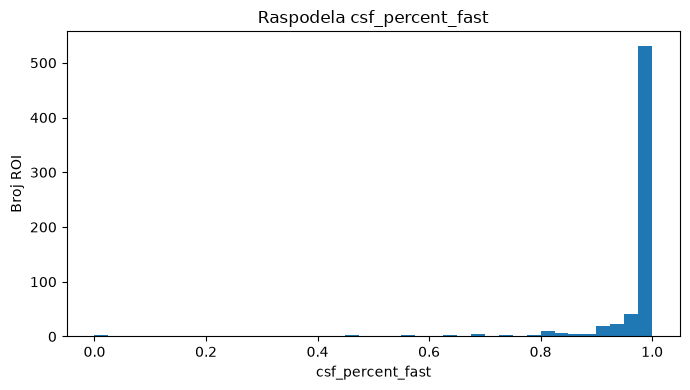

In [59]:
# Vizuelizacija raspodela
for column in fit_features:
    plt.figure(figsize=(7, 4))

    plt.hist(
        df[column].dropna(),
        bins=40,
    )

    plt.xlabel(column)
    plt.ylabel("Broj ROI")
    plt.title(f"Raspodela {column}")
    plt.tight_layout()
    plt.show()

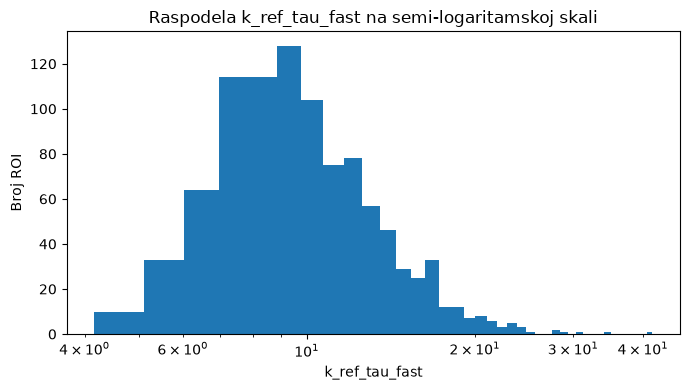

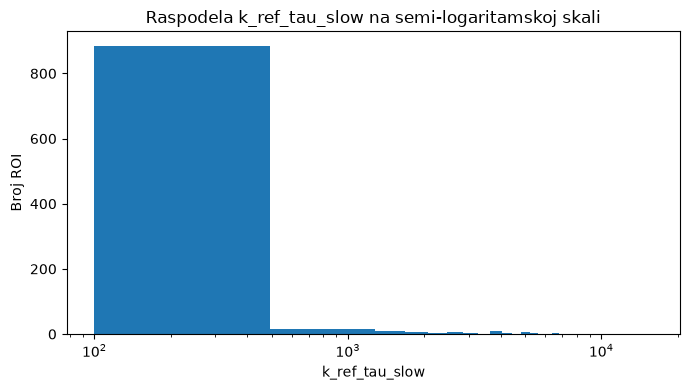

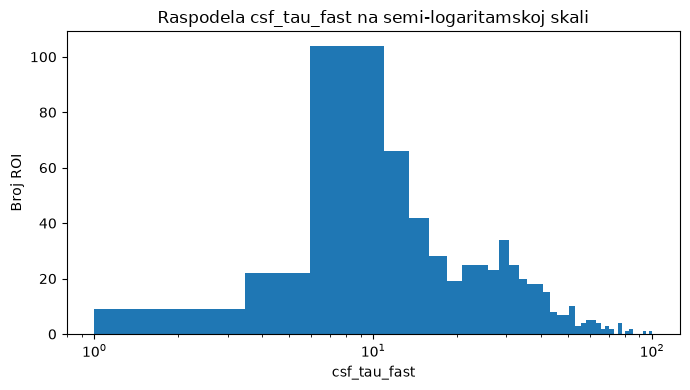

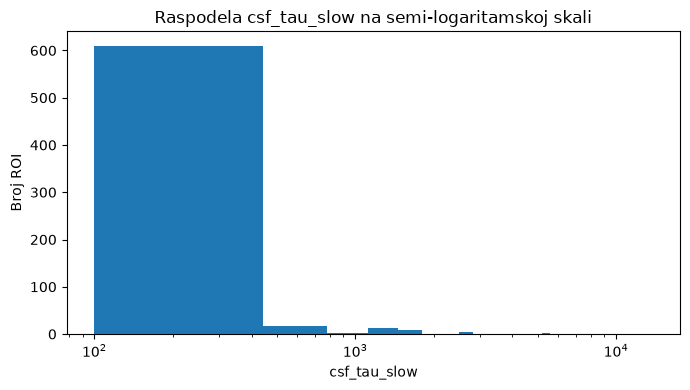

In [60]:
# Vremenske konstante (log x-osa)
for column in tau_columns:
    values = df.loc[df[column] > 0, column].dropna()

    plt.figure(figsize=(7, 4))
    plt.hist(values, bins=40)
    plt.xscale("log")
    plt.xlabel(column)
    plt.ylabel("Broj ROI")
    plt.title(f"Raspodela {column} na semi-logaritamskoj skali")
    plt.tight_layout()
    plt.show()

Ovde i definitivno vidimo da se veliki udeo `k_ref_tau_slow` i `csf_tau_slow` nalazi na samoj donjoj granici vrednosti, pa je zasigurno ne možemo posmatrati kao verodostojan prikaz kalcijumske kinetike.

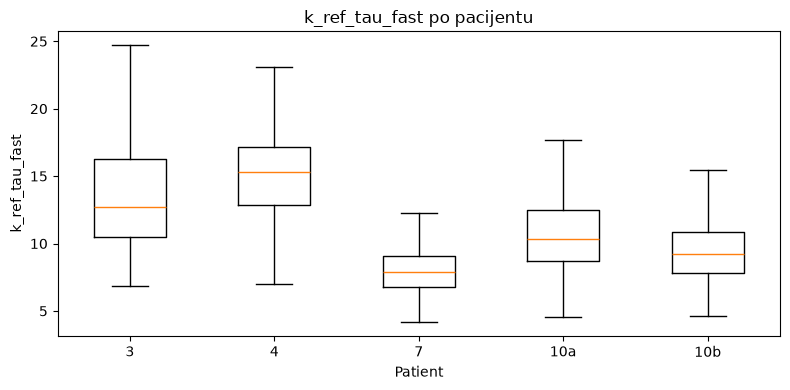

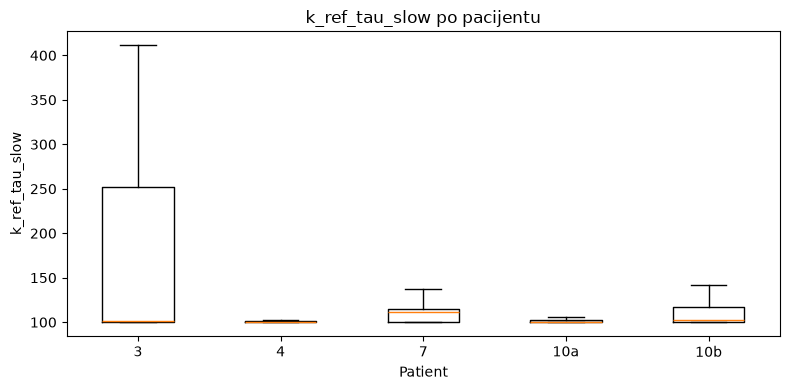

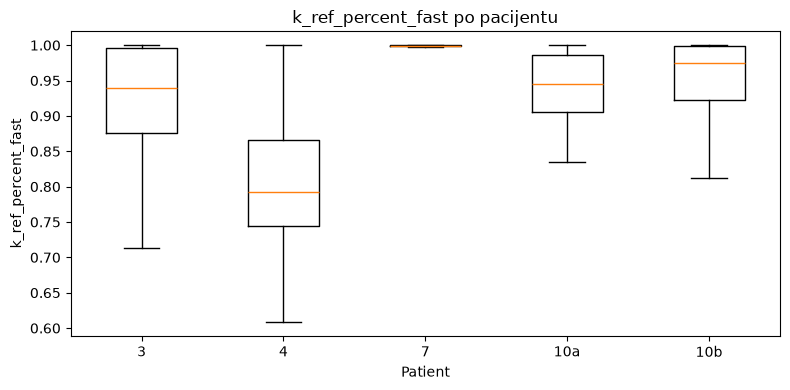

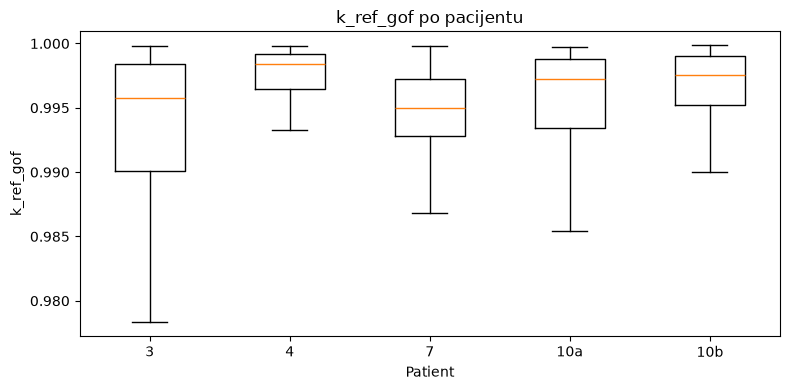

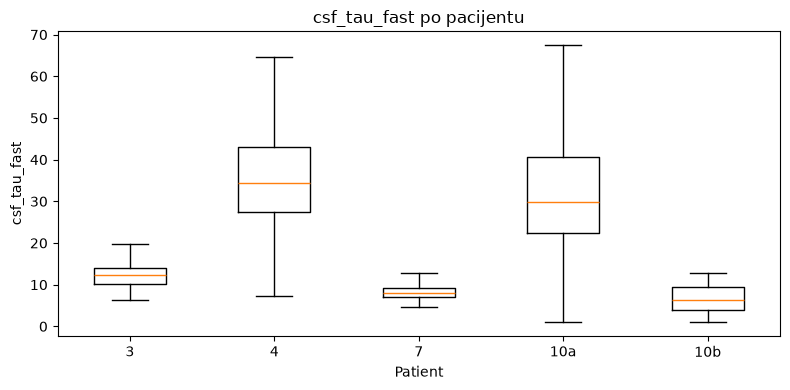

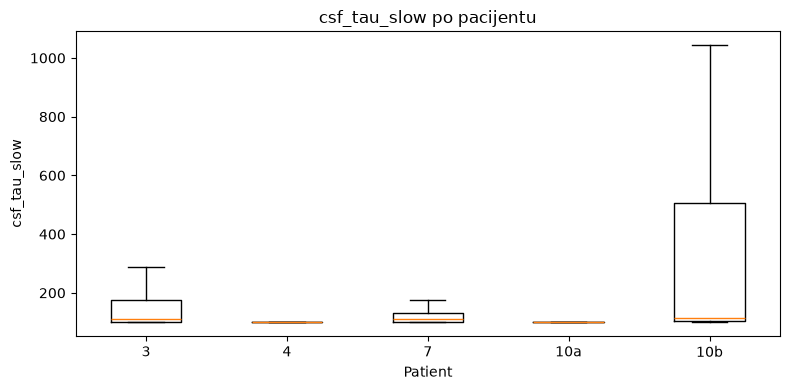

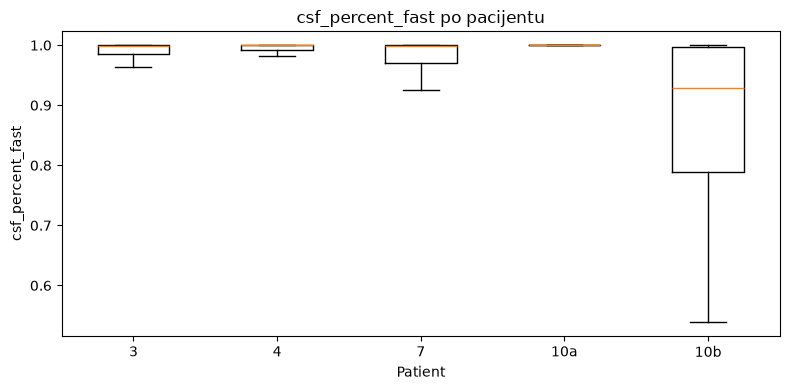

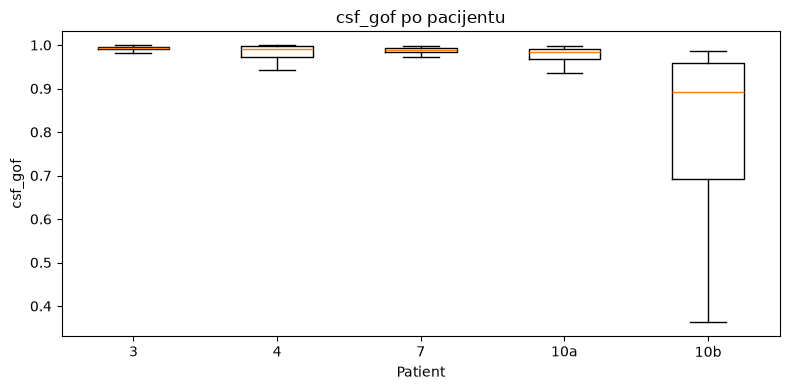

In [61]:
# Parametri po pacijentu (boksplot)
boxplot_features = [
    "k_ref_tau_fast",
    "k_ref_tau_slow",
    "k_ref_percent_fast",
    "k_ref_gof",
    "csf_tau_fast",
    "csf_tau_slow",
    "csf_percent_fast",
    "csf_gof",
]

for feature in boxplot_features:
    data_to_plot = [
        df.loc[
            df["patient_id"].astype(str) == patient,
            feature,
        ].dropna()
        for patient in patient_order
    ]

    plt.figure(figsize=(8, 4))
    plt.boxplot(
        data_to_plot,
        tick_labels=patient_order,
        showfliers=False,
    )
    plt.xlabel("Patient")
    plt.ylabel(f"{feature}")
    plt.title(f"{feature} po pacijentu")
    plt.tight_layout()
    plt.show()

Na osnovu boksplotova ne vidimo nikakav obrazac koji odgovara različitim klasama. Postoji variranje među uzorcima, ali ništa što bi ukazalo na mogućnost pouzdanog razdvajanja klasa na osnovu parametara fita.

In [62]:
# Analiza CSF fitova samo za ćelije koje odgovaraju na CSF

# Definisanje skupa
csf_fit_eda = df.loc[
    df["csf_fit_valid"]
].copy()

csf_fit_eda.shape

(666, 80)

In [63]:
# Pregled po pacijentu
csf_fit_summary_by_patient = (
    csf_fit_eda
    .groupby(
        [
            "patient_id",
            "class_label",
        ]
    )[csf_fit_features]
    .median()
)

csf_fit_summary_by_patient

,,csf_free_coef,csf_coef_fast,csf_tau_fast,csf_coef_slow,csf_tau_slow,csf_gof,csf_percent_fast
patient_id,class_label,,,,,,,
10a,SMA,0.041042,3.004047,29.812651,1.123278e-07,100.000010,0.983295,1.000000
10b,SMA,0.015700,0.173051,6.403529,1.548792e-02,115.863154,0.893049,0.929255
3,ALS,0.010638,3.056352,12.242562,3.985263e-03,111.334641,0.993099,0.998720
4,ALS,0.063134,1.643621,34.371445,6.542729e-06,100.000568,0.991206,0.999988
7,Control,0.009272,2.736759,8.081742,5.418286e-03,111.236674,0.989271,0.997911


In [64]:
# Korelacija između parametara fita za K+
k_fit_corr = (
    df.loc[df["k_ref_fit_valid"], k_fit_features]
    .corr(method="spearman")
)

k_fit_corr.round(3)

,k_ref_free_coef,k_ref_coef_fast,k_ref_tau_fast,k_ref_coef_slow,k_ref_tau_slow,k_ref_gof,k_ref_percent_fast
k_ref_free_coef,1.000,0.085,0.028,-0.373,0.692,0.214,0.353
k_ref_coef_fast,0.085,1.000,-0.090,-0.196,0.275,-0.211,0.460
k_ref_tau_fast,0.028,-0.090,1.000,0.120,-0.119,0.142,-0.161
k_ref_coef_slow,-0.373,-0.196,0.120,1.000,-0.304,0.091,-0.933
k_ref_tau_slow,0.692,0.275,-0.119,-0.304,1.000,0.020,0.349
k_ref_gof,0.214,-0.211,0.142,0.091,0.020,1.000,-0.093
k_ref_percent_fast,0.353,0.460,-0.161,-0.933,0.349,-0.093,1.000


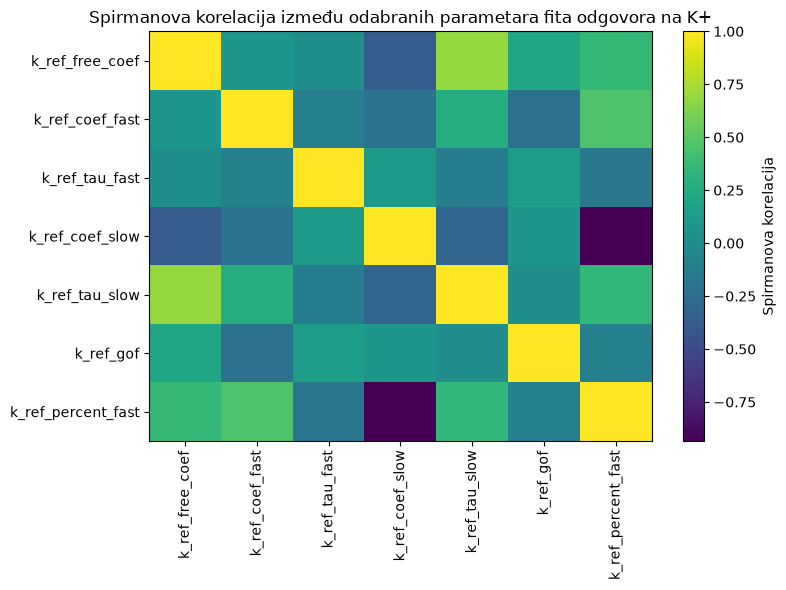

In [65]:
# Vizuelizacija
plt.figure(figsize=(8, 6))
plt.imshow(k_fit_corr, aspect="auto")
plt.colorbar(label="Spirmanova korelacija")

plt.xticks(
    ticks=np.arange(len(k_fit_corr.columns)),
    labels=k_fit_corr.columns,
    rotation=90,
)

plt.yticks(
    ticks=np.arange(len(k_fit_corr.index)),
    labels=k_fit_corr.index,
)

plt.title("Spirmanova korelacija između odabranih parametara fita odgovora na K+")
plt.tight_layout()
plt.show()

In [66]:
# Korelacija CSF
csf_fit_corr = (
    df.loc[df["csf_fit_valid"], csf_fit_features]
    .corr(method="spearman")
)

csf_fit_corr.round(3)

,csf_free_coef,csf_coef_fast,csf_tau_fast,csf_coef_slow,csf_tau_slow,csf_gof,csf_percent_fast
csf_free_coef,1.000,0.052,0.248,-0.030,0.157,-0.043,0.009
csf_coef_fast,0.052,1.000,0.069,-0.257,-0.132,0.175,0.390
csf_tau_fast,0.248,0.069,1.000,-0.484,-0.525,-0.212,0.464
csf_coef_slow,-0.030,-0.257,-0.484,1.000,0.665,0.332,-0.982
csf_tau_slow,0.157,-0.132,-0.525,0.665,1.000,0.194,-0.660
csf_gof,-0.043,0.175,-0.212,0.332,0.194,1.000,-0.251
csf_percent_fast,0.009,0.390,0.464,-0.982,-0.660,-0.251,1.000


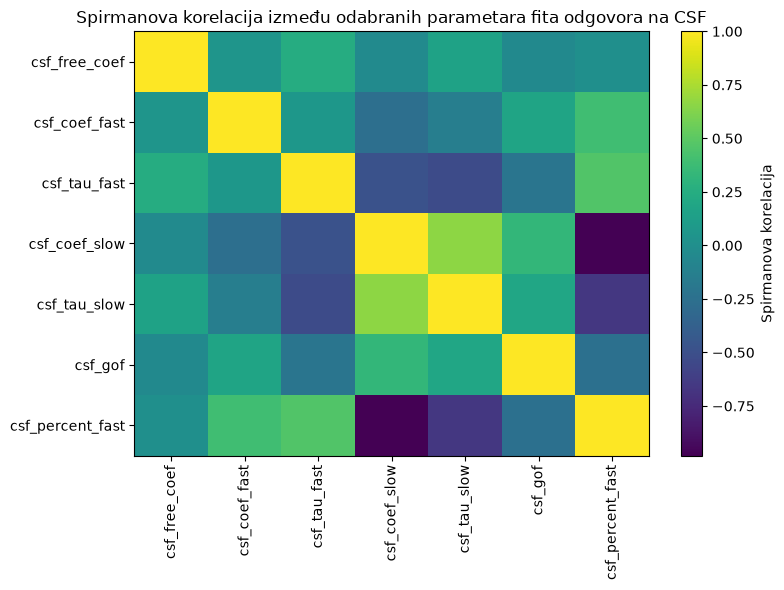

In [67]:
# Vizuelizacija
plt.figure(figsize=(8, 6))
plt.imshow(csf_fit_corr, aspect="auto")
plt.colorbar(label="Spirmanova korelacija")

plt.xticks(
    ticks=np.arange(len(csf_fit_corr.columns)),
    labels=csf_fit_corr.columns,
    rotation=90,
)

plt.yticks(
    ticks=np.arange(len(csf_fit_corr.index)),
    labels=csf_fit_corr.index,
)

plt.title("Spirmanova korelacija između odabranih parametara fita odgovora na CSF")
plt.tight_layout()
plt.show()

In [68]:
# Korelacija parametara fita i osobina odgovora
fit_peak_features = [
    "k_ref_amplitude",
    "k_ref_half_width",
    "k_ref_integral",
    *k_fit_features,

    "csf_amplitude",
    "csf_half_width",
    "csf_integral",
    *csf_fit_features,
]

fit_peak_corr = (
    df[fit_peak_features]
    .corr(method="spearman")
)

fit_peak_corr.round(3)

,k_ref_amplitude,k_ref_half_width,k_ref_integral,k_ref_free_coef,k_ref_coef_fast,k_ref_tau_fast,k_ref_coef_slow,k_ref_tau_slow,k_ref_gof,k_ref_percent_fast,csf_amplitude,csf_half_width,csf_integral,csf_free_coef,csf_coef_fast,csf_tau_fast,csf_coef_slow,csf_tau_slow,csf_gof,csf_percent_fast
k_ref_amplitude,1.000,0.022,0.729,0.051,0.985,-0.072,-0.088,0.222,-0.181,0.360,0.443,-0.545,-0.042,-0.155,0.436,-0.493,0.232,0.321,0.196,-0.155
k_ref_half_width,0.022,1.000,0.560,0.102,-0.026,0.892,0.222,-0.004,0.067,-0.249,0.097,0.358,0.201,0.074,0.087,0.352,-0.112,-0.035,0.069,0.104
k_ref_integral,0.729,0.560,1.000,0.098,0.674,0.429,0.267,0.147,-0.084,-0.049,0.423,-0.124,0.113,-0.001,0.407,-0.065,0.105,0.166,0.251,-0.048
k_ref_free_coef,0.051,0.102,0.098,1.000,0.085,0.028,-0.373,0.692,0.214,0.353,0.035,-0.050,-0.018,0.094,0.036,-0.070,0.009,0.077,-0.069,-0.018
k_ref_coef_fast,0.985,-0.026,0.674,0.085,1.000,-0.090,-0.196,0.275,-0.211,0.460,0.436,-0.563,-0.061,-0.161,0.428,-0.507,0.230,0.336,0.159,-0.153
k_ref_tau_fast,-0.072,0.892,0.429,0.028,-0.090,1.000,0.120,-0.119,0.142,-0.161,0.110,0.480,0.294,0.108,0.108,0.485,-0.205,-0.148,0.004,0.199
k_ref_coef_slow,-0.088,0.222,0.267,-0.373,-0.196,0.120,1.000,-0.304,0.091,-0.933,0.086,0.220,0.118,0.085,0.071,0.261,-0.026,-0.115,0.245,0.034
k_ref_tau_slow,0.222,-0.004,0.147,0.692,0.275,-0.119,-0.304,1.000,0.020,0.349,0.039,-0.186,-0.105,-0.038,0.050,-0.186,0.088,0.135,-0.072,-0.086
k_ref_gof,-0.181,0.067,-0.084,0.214,-0.211,0.142,0.091,0.020,1.000,-0.093,0.001,0.234,-0.007,0.195,-0.005,0.210,-0.117,-0.162,0.096,0.104
k_ref_percent_fast,0.360,-0.249,-0.049,0.353,0.460,-0.161,-0.933,0.349,-0.093,1.000,0.068,-0.372,-0.126,-0.121,0.078,-0.391,0.077,0.177,-0.173,-0.055


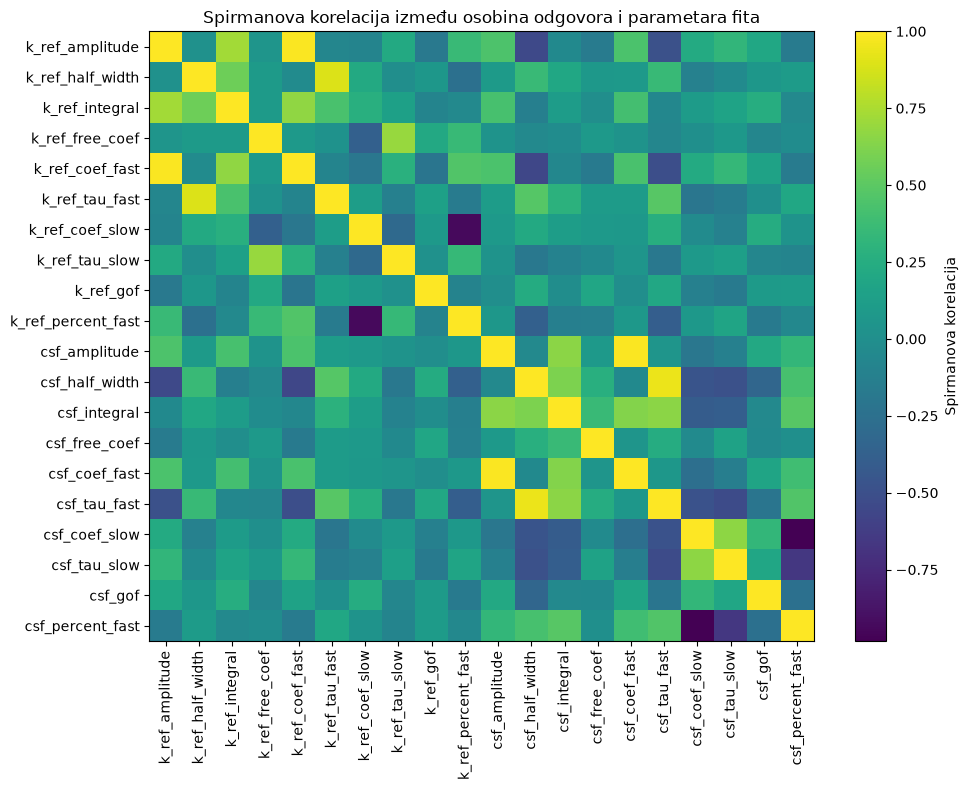

In [69]:
# Vizuelizacija
plt.figure(figsize=(10, 8))
plt.imshow(fit_peak_corr, aspect="auto")
plt.colorbar(label="Spirmanova korelacija")

plt.xticks(
    ticks=np.arange(len(fit_peak_corr.columns)),
    labels=fit_peak_corr.columns,
    rotation=90,
)

plt.yticks(
    ticks=np.arange(len(fit_peak_corr.index)),
    labels=fit_peak_corr.index,
)

plt.title("Spirmanova korelacija između osobina odgovora i parametara fita")
plt.tight_layout()
plt.show()

In [70]:
# Odnos između parametara fita i izmerene amplitude
df["k_ref_fitted_component"] = (
    df["k_ref_coef_fast"] # znamo jer y(0) - a = b + c
    + df["k_ref_coef_slow"]
)

df["csf_fitted_component"] = (
    df["csf_coef_fast"]
    + df["csf_coef_slow"]
)

df[
    [
        "k_ref_amplitude",
        "k_ref_fitted_component",
        "csf_amplitude",
        "csf_fitted_component",
    ]
].corr(method="spearman")

,k_ref_amplitude,k_ref_fitted_component,csf_amplitude,csf_fitted_component
k_ref_amplitude,1.000000,0.994794,0.443324,0.444142
k_ref_fitted_component,0.994794,1.000000,0.447420,0.447050
csf_amplitude,0.443324,0.447420,1.000000,0.994040
csf_fitted_component,0.444142,0.447050,0.994040,1.000000


Vrednosti korelacije su, uopšteno govoreći, matematički očekivane. Na primer: 
- I za K+ i za CSF je prisutna veoma visoka korelacija između izmerene amplitude i `b + c` komponenti. Stoga možemo reći da `coef_fast` i `coef_slow` praktično reprodukuju amplitudu, čija vrednost je već prisutna;
- `coef_slow` i `percent_slow` imaju vrednost korelacije `-0.933` i `-0.982` za K+ i CSF redom, što je sasvim očekivano ako znamo da važi $\%_{fast}=\frac{b}{b+c}$. Stoga, `coef_fast`, `coef_slow` i `percent_fast` nisu nezavisni prediktori.

In [71]:
# Ispitivanje kvaliteta fita
df[
    [
        "k_ref_gof",
        "csf_gof",
    ]
].describe()

,k_ref_gof,csf_gof
count,973.000000,666.000000
mean,0.993455,0.966987
std,0.027189,0.092413
min,0.254209,-0.026127
25%,0.993558,0.978845
50%,0.996943,0.989081
75%,0.998725,0.993651
max,0.999868,0.999690


In [72]:
df.groupby("experiment_id")[
    [
        "k_ref_gof",
        "csf_gof",
    ]
].describe()

k_ref_gof                                                    \
                      count      mean       std       min       25%       50%   
experiment_id                                                                   
patient_10a_exp_1     227.0  0.994719  0.006733  0.949685  0.993392  0.997252   
patient_10b_exp_1     161.0  0.993959  0.011964  0.898942  0.994750  0.996854   
patient_10b_exp_2     140.0  0.990819  0.063162  0.254209  0.996197  0.998851   
patient_3_exp_1       161.0  0.993327  0.006874  0.958759  0.990104  0.995771   
patient_4_exp_1       103.0  0.991961  0.033861  0.672116  0.996495  0.998426   
patient_7_exp_1       181.0  0.994425  0.005051  0.949112  0.992780  0.995010   

                                      csf_gof                                \
                        75%       max   count      mean       std       min   
experiment_id                                                                 
patient_10a_exp_1  0.998764  0.999755   214.0  0.964909  0.045833  0.761698   
patient_10b_exp_1  0.998173  0.999587    10.0  0.848952  0.194732  0.362809   
patient_10b_exp_2  0.999441  0.999868    22.0  0.698861  0.361533 -0.026127   
patient_3_exp_1    0.998378  0.999807   146.0  0.992111  0.005555  0.954291   
patient_4_exp_1    0.999195  0.999796    95.0  0.981230  0.027485  0.794625   
patient_7_exp_1    0.997203  0.999808   179.0  0.980968  0.033676  0.760904   

                                                           
                        25%       50%       75%       max  
experiment_id                                              
patient_10a_exp_1  0.968131  0.983295  0.991131  0.997698  
patient_10b_exp_1  0.844455  0.923377  0.969014  0.979326  
patient_10b_exp_2  0.546824  0.866402  0.953517  0.985614  
patient_3_exp_1    0.990103  0.993099  0.995968  0.999274  
patient_4_exp_1    0.972965  0.991206  0.996746  0.999690  
patient_7_exp_1    0.984564  0.989271  0.992515  0.998611

Fitovi za K+ su konzistentno veoma dobri. Fitovi CSF odgovora više variraju:
- ALS `3` i ALS `4`, kao i kontrola `7` imaju uglavnom visoku `gof` vrednost za oba fita;
- SMA `10a` ima nešto lošiji ali i dalje dobar fit;
- SMA `10b` ima malo fitova, manju prosečnu vrednost `gof` koja više varira.

Na osnovu ovoga možemo pretpostaviti da će CSF `gof` biti jak identifikator `10b` eksperimenata, i tako može poboljšati klasifikaciju na nivou ROI, iako ne predstavlja indikator stanja bolesti.

Za kraj ćemo definisati dve numeričke promenljive koje mogu biti korisne prilikom ispitivanja parametara fita, a koje se odnose na prisustvo validnog K+/CSF fita.

In [73]:
df["k_ref_fit_valid_int"] = (
    df["k_ref_fit_valid"].astype(int)
)

df["csf_fit_valid_int"] = (
    df["csf_fit_valid"].astype(int)
)

### Čuvanje tabele

Budući da smo u naš DataFrame dodali promenljive: 
- `csf_response_detected_int`,
- `csf_multiple_responses_int`,
- `csf_to_k_amplitude_ratio`,
- `csf_to_k_integral_ratio`,
- `k_ref_fit_valid_int`,
- `csf_fit_valid_int`,
 
možemo sačuvati modifikovanu tabelu.

In [74]:
# Čuvanje finalne tabele
ENGINEERED_TABLE_PATH = (
    EXTRACTED_DIR
    / "roi_features_engineered.csv"
)

diagnostic_only_columns = [
    "k_ref_fitted_component",
    "csf_fitted_component",
]

engineered_df = df.drop(
    columns=diagnostic_only_columns,
    errors="ignore",
).copy()

unexpected_diagnostic_columns = (
    set(diagnostic_only_columns)
    .intersection(
        engineered_df.columns
    )
)

assert not unexpected_diagnostic_columns

assert len(engineered_df) == len(df)

engineered_df.to_csv(
    ENGINEERED_TABLE_PATH,
    index=False,
)

In [75]:
engineered_df.shape

(997, 82)

Dimenzije izgledaju dobro, uzimajući u obzir da smo dodali pomenutih šest promenljivih u `roi_features_modeling.csv` tabelu.

Sada možemo preći na početne korake kreiranja modela, i to u `03_modeling.ipynb` notebook-u.